# ¿Qué mueve el precio de la papa? Análisis y modelado del precio de la Papa Superior en Corabastos (2019–2025)

---

> *"El precio de la papa no solo depende de cuánta papa llega al mercado. Este proyecto busca demostrar qué variables realmente lo explican — y en qué medida."*

---

**Equipo:** Esteban Mesa · Farith Lopez · Milena Moreno · Alex Martinez  
**Programa:** Bootcamp de Análisis de Datos 2026  
**Fecha:** Abril 2026

---

## Resumen Ejecutivo

La papa Superior es uno de los productos agrícolas con mayor peso en la canasta familiar del centro del país en Colombia. Su precio fluctúa de forma significativa a lo largo del año, afectando tanto a productores, comerciantes y consumidores finales. Este proyecto analiza los datos históricos de abastecimiento y precio de la papa Superior en *Corabastos* — la principal central mayorista de Colombia — entre *2019 y 2025*, con el objetivo de identificar qué variables explican mejor las variaciones en el precio.

### ¿Cuál era la hipótesis inicial?
La creencia común en el sector es simple: **a mayor abastecimiento, menor precio**. Es decir, cuando llega más papa al mercado, el precio baja. Este proyecto pone a prueba esa hipótesis con datos reales.

### ¿Qué encontramos?

| Modelo | Variables usadas | R² | ¿Qué significa? |
|--------|-----------------|----|-----------------|
| M1 | Solo abastecimiento | 0.01 | El abastecimiento casi no explica el precio |
| M2 | + Inflación (IPC) | 0.08 | La inflación ayuda poco por sí sola |
| M3 | + Precio anterior + mes | 0.76 | El precio pasado y la estacionalidad son clave |
| M4 | + Costos de producción | 0.69 | Los costos solos tampoco son suficientes |
| M5 | Todo junto | **0.85** | El modelo completo explica el 85% del precio |

**Conclusión principal:** el precio de la papa tiene una dinámica mucho más compleja que la simple oferta-demanda. La inercia del precio (lo que costó el mes anterior), la estacionalidad y los costos de producción explican mucho más que el volumen de oferta en plaza.

---

### Fuentes de datos

| Fuente | Variable | Período | Frecuencia |
|--------|----------|---------|------------|
| Observatorio FNFP | Precio mayorista papa Superior ($/kg) | 2013–2026 | Mensual |
| Observatorio FNFP | Abastecimiento papa Superior (toneladas) | 2013–2025 | Mensual |
| Observatorio FNFP | Costos de producción papa Superior | 2019–2025 | Mensual |
| Banco de la República | IPC de alimentos | 2019–2025 | Mensual |

> **Repositorio:** [github.com/estebanmesa147-boop/proyecto_papa_superior-](https://github.com/estebanmesa147-boop/proyecto_papa_superior-)  
> **Datos disponibles en:** `data/raw/`

---
## Sección 0 — Librerías y configuración

Antes de comenzar el análisis, cargamos todas las herramientas de Python que vamos a usar a lo largo del proyecto. También definimos las rutas donde están guardados los datos y el orden correcto de los meses en español.

In [1]:
# --- Librerías de manipulación de datos ---
import pandas as pd       # manejo de tablas de datos (dataframes)
import numpy as np        # operaciones numéricas y matemáticas
import os                 # manejo de rutas de archivos del sistema

# --- Librerías de visualización ---
import matplotlib.pyplot as plt          # gráficas base
import matplotlib.ticker as mticker      # formato de ejes (ej: mostrar $1,000 en vez de 1000)
import seaborn as sns                    # gráficas estadísticas con mejor estética

# --- Librerías estadísticas ---
from scipy import stats                                  # correlación de Pearson
from statsmodels.tsa.seasonal import seasonal_decompose  # descomposición de series de tiempo

# --- Librerías de machine learning ---
from sklearn.linear_model import LinearRegression        # modelo de regresión lineal
from sklearn.metrics import mean_absolute_error, mean_squared_error  # métricas de error

# --- Configuración visual global ---
# Estas líneas hacen que todas las gráficas del proyecto tengan el mismo estilo
sns.set_theme(style='whitegrid')          # fondo con cuadrícula blanca
plt.rcParams['figure.dpi'] = 120          # resolución alta para las gráficas
plt.rcParams['font.family'] = 'sans-serif'

# --- RUTAS DE ARCHIVOS (relativas — funcionan en cualquier PC) ---
# BASE apunta a la carpeta donde está este notebook
# ROOT sube un nivel para llegar a la raíz del proyecto
BASE      = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
ROOT      = os.path.dirname(BASE)
RAW       = os.path.join(ROOT, 'data', 'raw')        # archivos originales sin tocar
PROCESSED = os.path.join(ROOT, 'data', 'processed')  # archivos limpios y gráficas

print("RAW:", RAW)
print("PROCESSED:", PROCESSED)

# --- ORDEN CORRECTO DE LOS MESES EN ESPAÑOL ---
# Se define aquí para reutilizarlo en todo el proyecto
# Sin esto, pandas los ordenaría alfabéticamente (Abril, Agosto, Diciembre...)
meses_orden = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
               'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']

# Diccionario para convertir nombre de mes a número (ej: 'Enero' → '01')
mes_num = {m: str(i+1).zfill(2) for i, m in enumerate(meses_orden)}

print('\n✅ Librerías cargadas correctamente')

RAW: c:\Users\User\Desktop\Analisis de datos 2026\proyecto_papa_superior-\data\raw
PROCESSED: c:\Users\User\Desktop\Analisis de datos 2026\proyecto_papa_superior-\data\processed

✅ Librerías cargadas correctamente


---
## Sección 1 — Carga y limpieza de datos

En esta sección preparamos todos los datos que usaremos en el análisis. Los datos crudos tienen varios problemas de formato que debemos corregir antes de poder trabajar con ellos:

- El archivo de abastecimiento tiene **problemas de encoding** (caracteres especiales rotos)
- La columna de mes tiene **inconsistencias de capitalización** ('julio' en minúscula)
- Las fechas vienen como **texto** y hay que convertirlas a formato de fecha
- Los datos de precio y abastecimiento están a **diferente granularidad** (semanal vs diario) y hay que unificarlos a nivel mensual

Al final de esta sección tendremos un **dataset maestro limpio** con 84 filas (7 años × 12 meses) y todas las variables necesarias para el análisis.

In [2]:
# --- PASO 1: Cargar los archivos originales sin modificar nada ---
# Siempre cargamos primero sin tocar para tener los datos crudos como referencia

# El CSV de abastecimiento requiere encoding='latin1' porque tiene tildes y
# caracteres especiales que el encoding por defecto (UTF-8) no puede leer
df_abast_raw = pd.read_csv(
    os.path.join(RAW, 'ABASTECIMIENTO_PAPA_2013_2025.csv'),
    encoding='latin1'
)

# El archivo de precios es un Excel con una sola hoja llamada 'Base Papa'
df_precios_raw = pd.read_excel(
    os.path.join(RAW, 'Base_Precios_historica_13_2026.xlsx'),
    sheet_name='Base Papa'
)

print("Abastecimiento cargado:", df_abast_raw.shape, "→", df_abast_raw.shape[0], "registros diarios")
print("Precios cargado:", df_precios_raw.shape, "→", df_precios_raw.shape[0], "registros semanales")

Abastecimiento cargado: (888086, 12) → 888086 registros diarios
Precios cargado: (86898, 11) → 86898 registros semanales


In [3]:
# --- PASO 2: Limpiar el dataset de abastecimiento ---
# Trabajamos sobre una copia para no modificar el archivo original
df_abast = df_abast_raw.copy()

# Problema 1: La columna 'Año' llegó con encoding roto → aparece como 'AÃ±o'
# Solución: renombramos todas las columnas manualmente con los nombres correctos
df_abast.columns = [
    'Central', 'fecha', 'Cod_Depto', 'Cod_Mun',
    'Departamento', 'Municipio', 'variedad',
    'semana', 'Año', 'CantKg', 'mes', 'Toneladas'
]

# Problema 2: La columna 'mes' tiene inconsistencia — 'julio' está en minúscula
# mientras todos los demás meses tienen primera letra mayúscula
# Solución: str.capitalize() estandariza todo a primera letra mayúscula
df_abast['mes'] = df_abast['mes'].str.capitalize()

# Problema 3: La columna 'fecha' llegó como texto en formato 'dd/mm/yyyy'
# Solución: convertirla a tipo datetime para poder operar con fechas
df_abast['fecha'] = pd.to_datetime(df_abast['fecha'], format='%d/%m/%Y')

print("✅ Abastecimiento limpio")
print(df_abast[['Central','fecha','variedad','Año','mes','Toneladas']].head(3).to_string())

✅ Abastecimiento limpio
  Central      fecha       variedad   Año    mes  Toneladas
0  Mercar 2013-01-02  Diacol Capiro  2013  Enero        9.0
1  Mercar 2013-01-03  Diacol Capiro  2013  Enero        9.5
2  Mercar 2013-01-04        Criolla  2013  Enero        5.5


In [4]:
# --- PASO 3: Filtrar abastecimiento ---
# Solo nos quedamos con los datos que necesitamos:
# Central = Corabastos (plaza mayorista de Bogotá)
# variedad = Superior (la variedad de papa que analizamos)
# Año entre 2019 y 2025 (nuestro período de análisis)
df_abast_filtrado = df_abast[
    (df_abast['Central']  == 'Corabastos') &
    (df_abast['variedad'] == 'Superior') &
    (df_abast['Año'].between(2019, 2025))
].copy()

print(f"Registros originales: {len(df_abast):,}")
print(f"Registros después del filtro: {len(df_abast_filtrado):,}")
print(f"Años disponibles: {sorted(df_abast_filtrado['Año'].unique())}")

Registros originales: 888,086
Registros después del filtro: 53,863
Años disponibles: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [5]:
# --- PASO 4: Limpiar el dataset de precios ---
df_precios = df_precios_raw.copy()

# Los meses en precios vienen en minúscula ('enero', 'febrero'...)
# Los capitalizamos para que coincidan con el formato de abastecimiento
# y poder unir las dos tablas correctamente más adelante
df_precios['mes'] = df_precios['mes'].str.capitalize()

# Filtrar: Bogotá D.C. + variedad Superior + 2019-2025
# Nota: usamos 'Bogotá D.C.' porque el SIPSA captura los precios mayoristas
# de Bogotá en Corabastos — es el proxy oficial de precio en esa central
df_precios_filtrado = df_precios[
    (df_precios['ciudad']   == 'Bogotá D.C.') &
    (df_precios['variedad'] == 'Superior') &
    (df_precios['year'].between(2019, 2025))
].copy()

# Nos quedamos solo con las columnas útiles
df_precios_filtrado = df_precios_filtrado[
    ['year', 'mes', 'semana', 'fecha3', 'precio']
].rename(columns={'year': 'Año', 'fecha3': 'fecha'})

print("✅ Precios limpios")
print(f"Registros: {len(df_precios_filtrado)} (registros semanales 2019-2025)")
print(f"Precio mínimo: ${df_precios_filtrado['precio'].min():,.0f}/kg")
print(f"Precio máximo: ${df_precios_filtrado['precio'].max():,.0f}/kg")

✅ Precios limpios
Registros: 366 (registros semanales 2019-2025)
Precio mínimo: $423/kg
Precio máximo: $3,000/kg


In [6]:
# --- PASO 5: Cargar y limpiar el IPC de alimentos ---
# IPC = Índice de Precios al Consumidor
# Mide cuánto han subido los precios de los alimentos respecto al año anterior
# Fuente: Banco de la República

# El archivo tiene 2 filas de encabezado antes de los datos → skiprows=2
df_ipc = pd.read_excel(
    os.path.join(RAW, 'graficador_seriesf.xlsx'),
    sheet_name='Datos', skiprows=2
)
df_ipc.columns = ['fecha', 'ipc_alimentos']

# Limpiar filas vacías y la fila de pie de página
df_ipc = df_ipc[df_ipc['fecha'].notna() & (df_ipc['fecha'] != '')]
df_ipc = df_ipc[~df_ipc['fecha'].astype(str).str.contains('Descargado')]
df_ipc['fecha'] = pd.to_datetime(df_ipc['fecha'], format='%d/%m/%Y')

# El IPC viene con coma decimal ('2,07') → convertir a punto ('2.07')
df_ipc['ipc_alimentos'] = df_ipc['ipc_alimentos'].astype(str).str.replace(',', '.').astype(float)
df_ipc = df_ipc[df_ipc['fecha'].dt.year.between(2019, 2025)].reset_index(drop=True)

# Construir índice acumulado base 100 = enero 2019
# El archivo tiene la VARIACIÓN ANUAL (ej: 5.8% = alimentos subieron 5.8% vs hace 12 meses)
# Necesitamos convertirlo a un índice que arranque en 100 y crezca mes a mes
# Fórmula: factor_mensual = (1 + variación_anual/100)^(1/12)
df_ipc['factor_mensual'] = (1 + df_ipc['ipc_alimentos'] / 100) ** (1/12)
df_ipc['indice'] = 100.0
for i in range(1, len(df_ipc)):
    df_ipc.loc[i, 'indice'] = df_ipc.loc[i-1, 'indice'] * df_ipc.loc[i, 'factor_mensual']

print("✅ IPC cargado y procesado")
print(f"Índice enero 2019: 100.0 (base)")
print(f"Índice diciembre 2025: {df_ipc.iloc[-1]['indice']:.2f}")
print(f"Interpretación: los alimentos costaban {df_ipc.iloc[-1]['indice']-100:.1f}% más en dic-2025 que en ene-2019")

✅ IPC cargado y procesado
Índice enero 2019: 100.0 (base)
Índice diciembre 2025: 188.65
Interpretación: los alimentos costaban 88.7% más en dic-2025 que en ene-2019


In [7]:
# --- PASO 6: Cargar y limpiar costos de producción ---
# Contiene costos por rubro (fertilizantes, mano de obra, transporte, etc.)
# para papa Superior en Boyacá y Cundinamarca — los departamentos que
# más abastecen a Corabastos. Período: 2019–2025
# Fuente: Observatorio FNFP

df_costos_raw = pd.read_excel(
    os.path.join(RAW, 'COSTOS_PAPA_DEPTOS.xlsx'),
    sheet_name='BASE_MAESTRA'
)

# Filtrar: papa Superior + Boyacá y Cundinamarca + 2019-2025
filtro = df_costos_raw[
    (df_costos_raw['VARIEDAD'] == 'Superior') &
    (df_costos_raw['DEPTO'].isin(['BOYACA', 'CUNDINAMARCA'])) &
    (df_costos_raw['AÑO'].between(2019, 2025))
].copy()

# Agregar precio por rubro y mes (hay múltiples registros por rubro)
costos_rubro = filtro.groupby(['AÑO','MES','RUBRO'])['PRECIO'].sum().reset_index()

# Pivotear: cada rubro se convierte en una columna separada
pivot = costos_rubro.pivot_table(
    index=['AÑO','MES'], columns='RUBRO', values='PRECIO', aggfunc='sum'
).reset_index()

pivot.columns = ['Año','mes','arriendo','costos_indirectos','empaques','enmiendas',
                 'fertilizantes','mano_obra','mipe','semilla','maquinaria','transporte']

# Costo total = suma de todos los rubros
pivot['costo_total'] = pivot[[
    'arriendo','costos_indirectos','empaques','enmiendas',
    'fertilizantes','mano_obra','mipe','semilla','maquinaria','transporte'
]].sum(axis=1)

# Escalar a millones de pesos para que los números sean más manejables
# (ej: 4.7 en vez de 4,700,000)
for col in ['fertilizantes','mano_obra','transporte','costo_total',
            'arriendo','semilla','empaques','mipe','enmiendas','maquinaria']:
    pivot[col] = pivot[col] / 1_000_000

print("✅ Costos cargados")
print(f"Shape: {pivot.shape}")
print(f"Costo total promedio por mes: ${pivot['costo_total'].mean():,.2f} millones")

✅ Costos cargados
Shape: (84, 13)
Costo total promedio por mes: $72.66 millones


In [8]:
# --- PASO 7: Preparar datos Coomproriente para comparación ---
# Coomproriente es la central mayorista de Boyacá
# La comparamos con Corabastos para el período 2024-2025
# Nota: el departamento tiene encoding roto → filtramos con str.contains

meses_orden_comp = meses_orden.copy()

df_abast_comp = df_abast[
    (df_abast['Central'] == 'Coomproriente') &
    (df_abast['variedad'] == 'Superior') &
    (df_abast['Departamento'].str.contains('BOYAC', na=False)) &
    (df_abast['Año'].between(2024, 2025))
].copy()
df_abast_comp['mes'] = df_abast_comp['mes'].str.capitalize()

df_abast_cora = df_abast[
    (df_abast['Central'] == 'Corabastos') &
    (df_abast['variedad'] == 'Superior') &
    (df_abast['Año'].between(2024, 2025))
].copy()

abast_comp_m = df_abast_comp.groupby(['Año','mes'], as_index=False)['Toneladas'].sum()
abast_cora_m = df_abast_cora.groupby(['Año','mes'], as_index=False)['Toneladas'].sum()
abast_comp_a = df_abast_comp.groupby('Año')['Toneladas'].sum().reset_index()
abast_cora_a = df_abast_cora.groupby('Año')['Toneladas'].sum().reset_index()

# Precios de referencia para cada central
df_p = pd.read_excel(os.path.join(RAW, 'Base_Precios_historica_13_2026.xlsx'), sheet_name='Base Papa')
df_p['mes'] = df_p['mes'].str.capitalize()

# Bogotá = proxy precio Corabastos
precio_cora_m = df_p[
    (df_p['ciudad'] == 'Bogotá D.C.') & (df_p['variedad'] == 'Superior') &
    (df_p['year'].between(2024, 2025))
].groupby(['year','mes'], as_index=False)['precio'].mean()
precio_cora_m.columns = ['Año','mes','precio']

# Duitama = proxy precio Coomproriente Boyacá
precio_comp_m = df_p[
    (df_p['ciudad'] == 'Duitama') & (df_p['variedad'] == 'Superior') &
    (df_p['year'].between(2024, 2025))
].groupby(['year','mes'], as_index=False)['precio'].mean()
precio_comp_m.columns = ['Año','mes','precio']

precio_cora_a = precio_cora_m.groupby('Año')['precio'].mean().reset_index()
precio_comp_a = precio_comp_m.groupby('Año')['precio'].mean().reset_index()

for df_temp in [abast_comp_m, abast_cora_m, precio_cora_m, precio_comp_m]:
    df_temp['mes'] = pd.Categorical(df_temp['mes'], categories=meses_orden_comp, ordered=True)
    df_temp.sort_values(['Año','mes'], inplace=True)
    df_temp.reset_index(drop=True, inplace=True)

print("✅ Datos Coomproriente preparados")
print(f"Corabastos 2024-2025: {abast_cora_a['Toneladas'].sum():,.0f} ton")
print(f"Coomproriente 2024-2025: {abast_comp_a['Toneladas'].sum():,.0f} ton")

✅ Datos Coomproriente preparados
Corabastos 2024-2025: 566,115 ton
Coomproriente 2024-2025: 21,842 ton


In [9]:
# --- PASO 8: Agregar a nivel mensual y construir el dataset maestro ---

# Abastecimiento diario → sumamos las toneladas por mes
abast_mensual = df_abast_filtrado.groupby(
    ['Año', 'mes'], as_index=False
)['Toneladas'].sum()

# Precios semanales → promediamos el precio por mes
precios_mensual = df_precios_filtrado.groupby(
    ['Año', 'mes'], as_index=False
)['precio'].mean().rename(columns={'precio': 'precio_promedio'})

# Unir abastecimiento y precios en un solo dataset
df_maestro = pd.merge(abast_mensual, precios_mensual, on=['Año', 'mes'], how='inner')
df_maestro['mes'] = pd.Categorical(df_maestro['mes'], categories=meses_orden, ordered=True)
df_maestro = df_maestro.sort_values(['Año', 'mes']).reset_index(drop=True)

# Crear columna de fecha (primer día de cada mes)
df_maestro['fecha'] = pd.to_datetime(
    df_maestro['Año'].astype(str) + '-' + df_maestro['mes'].astype(str).map(mes_num) + '-01'
)

# Unir IPC
df = df_maestro.copy()
df_ipc['fecha_merge'] = df_ipc['fecha'].values.astype('datetime64[M]').astype('datetime64[D]')
df['fecha_merge']     = df['fecha'].values.astype('datetime64[M]').astype('datetime64[D]')
df = pd.merge(df, df_ipc[['fecha_merge', 'ipc_alimentos', 'indice']], on='fecha_merge', how='left')

# Precio real deflactado: elimina el efecto de la inflación
# Precio real = (precio nominal / índice IPC) × 100
df['precio_real'] = (df['precio_promedio'] / df['indice']) * 100

# Unir costos
df = pd.merge(df, pivot, on=['Año','mes'], how='left')

# Guardar datasets procesados
df_maestro.to_csv(os.path.join(PROCESSED, 'papa_superior_corabastos_2019_2025.csv'), index=False)
df_maestro.to_parquet(os.path.join(PROCESSED, 'papa_superior_corabastos_2019_2025.parquet'), index=False)
df.to_csv(os.path.join(PROCESSED, 'papa_superior_corabastos_completo.csv'), index=False)
df.to_parquet(os.path.join(PROCESSED, 'papa_superior_corabastos_completo.parquet'), index=False)

print("✅ Dataset maestro creado")
print(f"Shape: {df.shape} — {len(df)} filas = 7 años × 12 meses")
print(f"Columnas: {df.columns.tolist()}")
df[['Año','mes','Toneladas','precio_promedio','precio_real','ipc_alimentos','costo_total']].head(6)

✅ Dataset maestro creado
Shape: (84, 20) — 84 filas = 7 años × 12 meses
Columnas: ['Año', 'mes', 'Toneladas', 'precio_promedio', 'fecha', 'fecha_merge', 'ipc_alimentos', 'indice', 'precio_real', 'arriendo', 'costos_indirectos', 'empaques', 'enmiendas', 'fertilizantes', 'mano_obra', 'mipe', 'semilla', 'maquinaria', 'transporte', 'costo_total']


,Año,mes,Toneladas,precio_promedio,precio_real,ipc_alimentos,costo_total
0,2019,Enero,21718.850015,772.680206,772.680206,2.07,45.038721
1,2019,Febrero,17933.900006,798.444778,796.939685,2.29,45.130302
2,2019,Marzo,20840.399999,871.406474,867.455791,3.24,45.914532
3,2019,Abril,17516.300000,1136.499939,1128.154147,3.45,51.359624
4,2019,Mayo,23682.049977,1056.201807,1044.999422,4.03,52.537736
5,2019,Junio,21918.900008,1109.630905,1093.441879,4.96,52.934381


---
## Sección 2 — Análisis Descriptivo

Antes de construir modelos, necesitamos entender los datos. En esta sección exploramos:
- **¿Cómo ha evolucionado el precio año a año?** ¿Qué años fueron más caros?
- **¿Cuánta papa ha llegado a Corabastos cada año?** ¿Hay tendencias en el abastecimiento?
- **¿El precio y el abastecimiento se mueven juntos o en direcciones opuestas?**

Los datos clave que encontramos:
- El **precio más bajo** fue en 2020 (~$480/kg en diciembre) — impacto del COVID
- El **precio más alto** fue en julio 2024 (~$2.651/kg) — crisis de costos de producción
- El **mayor abastecimiento** fue en 2022 y 2023 (~322.000 toneladas cada año)
- El **menor abastecimiento** fue en 2020 (~240.519 toneladas) — también por el COVID

In [10]:
# --- Estadísticas básicas por año ---
# Resumen numérico de precio y abastecimiento para cada año
# precio_std = desviación estándar, mide qué tan volátil fue el precio ese año
resumen = df_maestro.groupby('Año').agg(
    precio_min      = ('precio_promedio', 'min'),
    precio_max      = ('precio_promedio', 'max'),
    precio_medio    = ('precio_promedio', 'mean'),
    precio_std      = ('precio_promedio', 'std'),
    toneladas_total = ('Toneladas', 'sum'),
    toneladas_media = ('Toneladas', 'mean')
).round(2)

resumen.to_csv(os.path.join(PROCESSED, 'resumen_anual.csv'))
print("Estadísticas por año — Papa Superior Corabastos:")
print(resumen.to_string())

Estadísticas por año — Papa Superior Corabastos:
      precio_min  precio_max  precio_medio  precio_std  toneladas_total  toneladas_media
Año                                                                                     
2019      619.28     1136.50        890.14      153.56        273450.90         22787.57
2020      479.90     1081.97        718.30      194.30        240519.20         20043.27
2021      616.30     1491.87        975.96      270.57        276383.85         23031.99
2022      785.12     2577.62       1539.26      647.37        322754.35         26896.20
2023      925.62     1890.91       1385.75      282.32        322211.25         26850.94
2024     1195.65     2650.73       1714.86      506.34        291497.48         24291.46
2025      565.24     1735.54       1000.45      378.60        274617.05         22884.75


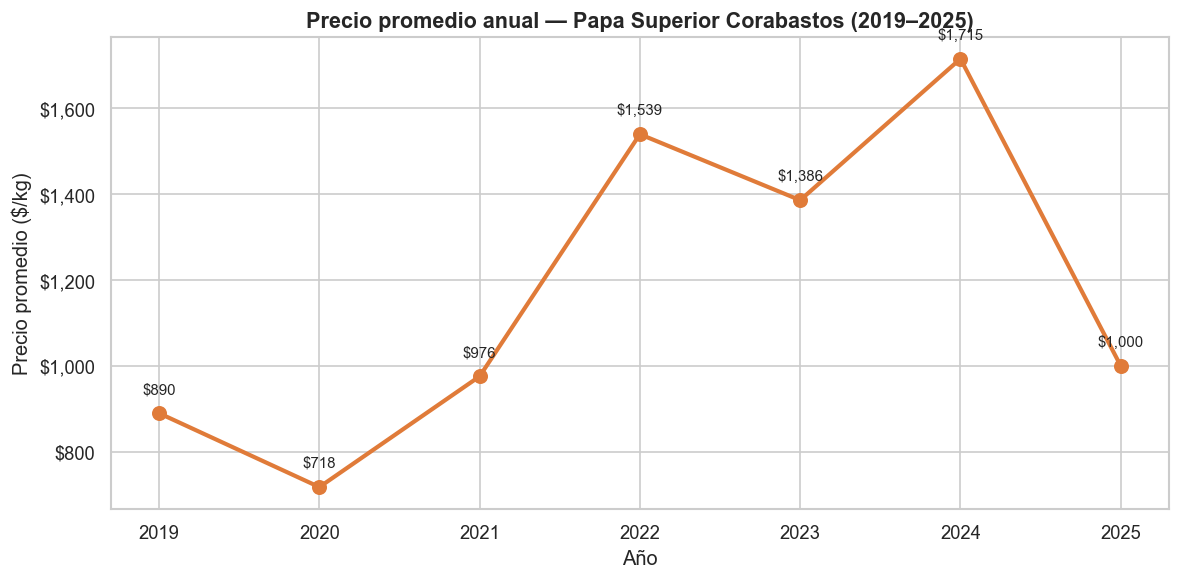

In [11]:
# --- Gráfica 1: Evolución anual del precio promedio ---
# ¿En qué años fue más caro comprar papa Superior en Corabastos?
precio_anual = df_maestro.groupby('Año')['precio_promedio'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(precio_anual['Año'], precio_anual['precio_promedio'],
        marker='o', linewidth=2.5, color='#E07B39', markersize=8)

for _, row in precio_anual.iterrows():
    ax.annotate(f"${row['precio_promedio']:,.0f}",
                xy=(row['Año'], row['precio_promedio']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_title('Precio promedio anual — Papa Superior Corabastos (2019–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Precio promedio ($/kg)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticks(precio_anual['Año'])
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_precio_anual.png'), bbox_inches='tight')
plt.show()

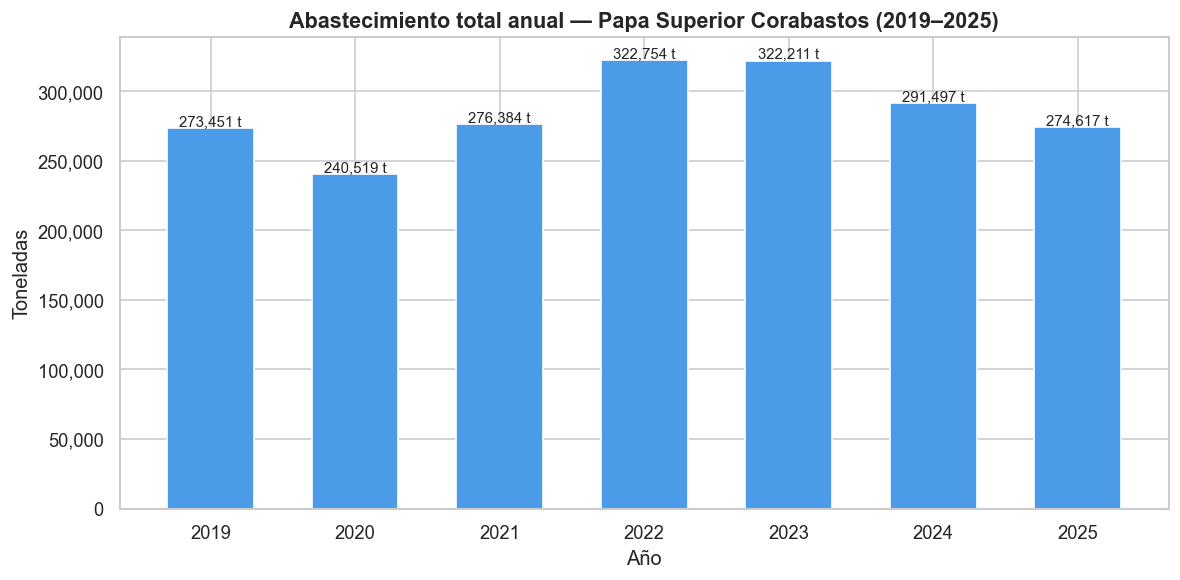

In [12]:
# --- Gráfica 2: Abastecimiento total anual ---
# ¿Cuántas toneladas de papa Superior llegaron a Corabastos cada año?
abast_anual = df_maestro.groupby('Año')['Toneladas'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(abast_anual['Año'], abast_anual['Toneladas'],
              color='#4C9BE8', width=0.6, edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1500,
            f"{bar.get_height():,.0f} t", ha='center', fontsize=9)

ax.set_title('Abastecimiento total anual — Papa Superior Corabastos (2019–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Toneladas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xticks(abast_anual['Año'])
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_abastecimiento_anual.png'), bbox_inches='tight')
plt.show()

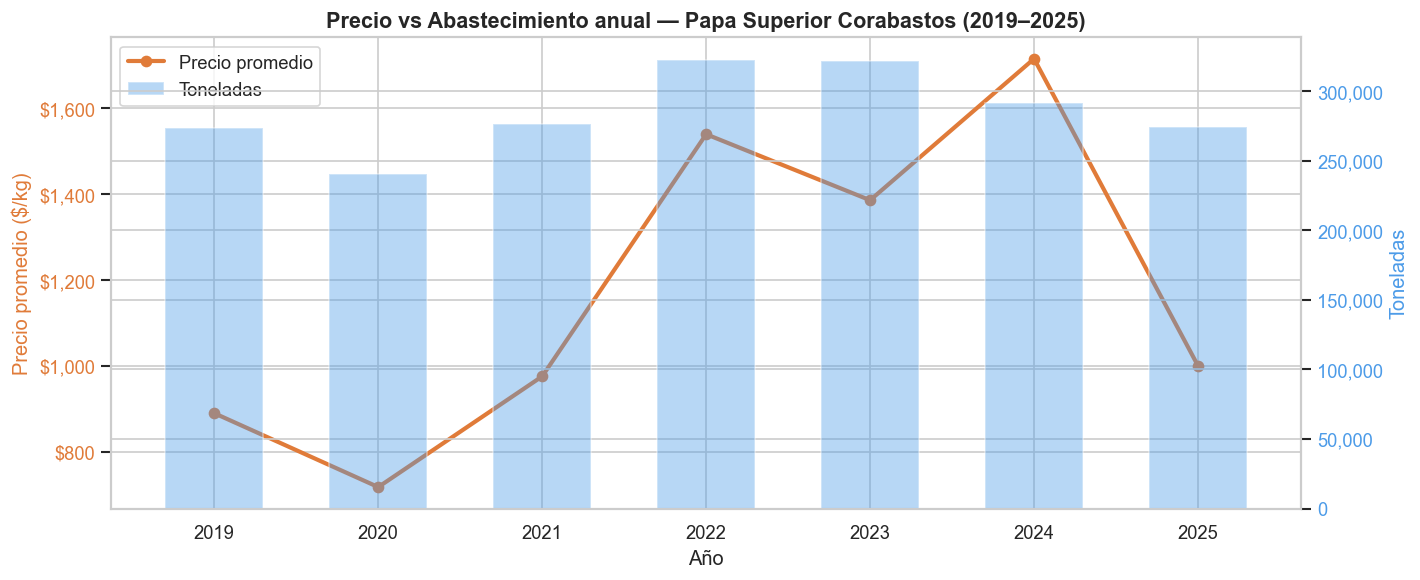

In [13]:
# --- Gráfica 3: Precio y abastecimiento en doble eje ---
# Esta gráfica muestra precio (línea) y toneladas (barras) juntos
# Si la hipótesis fuera cierta (más oferta = menor precio),
# esperaríamos ver que cuando las barras suben, la línea baja
fig, ax1 = plt.subplots(figsize=(12, 5))

color_precio = '#E07B39'
ax1.plot(precio_anual['Año'], precio_anual['precio_promedio'],
         marker='o', color=color_precio, linewidth=2.5, label='Precio promedio')
ax1.set_ylabel('Precio promedio ($/kg)', color=color_precio)
ax1.tick_params(axis='y', labelcolor=color_precio)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = ax1.twinx()
color_abast = '#4C9BE8'
ax2.bar(abast_anual['Año'], abast_anual['Toneladas'],
        color=color_abast, alpha=0.4, width=0.6, label='Toneladas')
ax2.set_ylabel('Toneladas', color=color_abast)
ax2.tick_params(axis='y', labelcolor=color_abast)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax1.set_title('Precio vs Abastecimiento anual — Papa Superior Corabastos (2019–2025)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Año')
ax1.set_xticks(precio_anual['Año'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_precio_vs_abastecimiento.png'), bbox_inches='tight')
plt.show()

---
## Sección 3 — Estacionalidad

La **estacionalidad** es un patrón que se repite en los mismos períodos cada año. Por ejemplo, si la papa siempre es más cara en abril y más barata en septiembre, eso es estacionalidad.

Para analizarla usamos tres enfoques:
1. **Líneas superpuestas por año:** si los patrones de precio se parecen entre años, hay estacionalidad
2. **Promedio histórico por mes:** muestra el precio "típico" de cada mes
3. **Descomposición de la serie:** separa el precio en tendencia + estacionalidad + residuo

> **¿Por qué es importante?** Si el precio tiene estacionalidad, los agricultores pueden planificar mejor cuándo vender y los compradores cuándo abastecerse.

In [14]:
# --- Preparar serie de tiempo con índice de fechas ---
# seasonal_decompose necesita un DataFrame con fechas como índice
df_ts = df.copy().set_index('fecha')
df_ts['mes_str'] = df_ts['mes'].astype(str)

años = sorted(df_ts['Año'].unique())
print(f"Serie de tiempo lista: {len(df_ts)} observaciones mensuales")
print(f"Período: {df_ts.index[0].strftime('%B %Y')} → {df_ts.index[-1].strftime('%B %Y')}")

Serie de tiempo lista: 84 observaciones mensuales
Período: January 2019 → December 2025


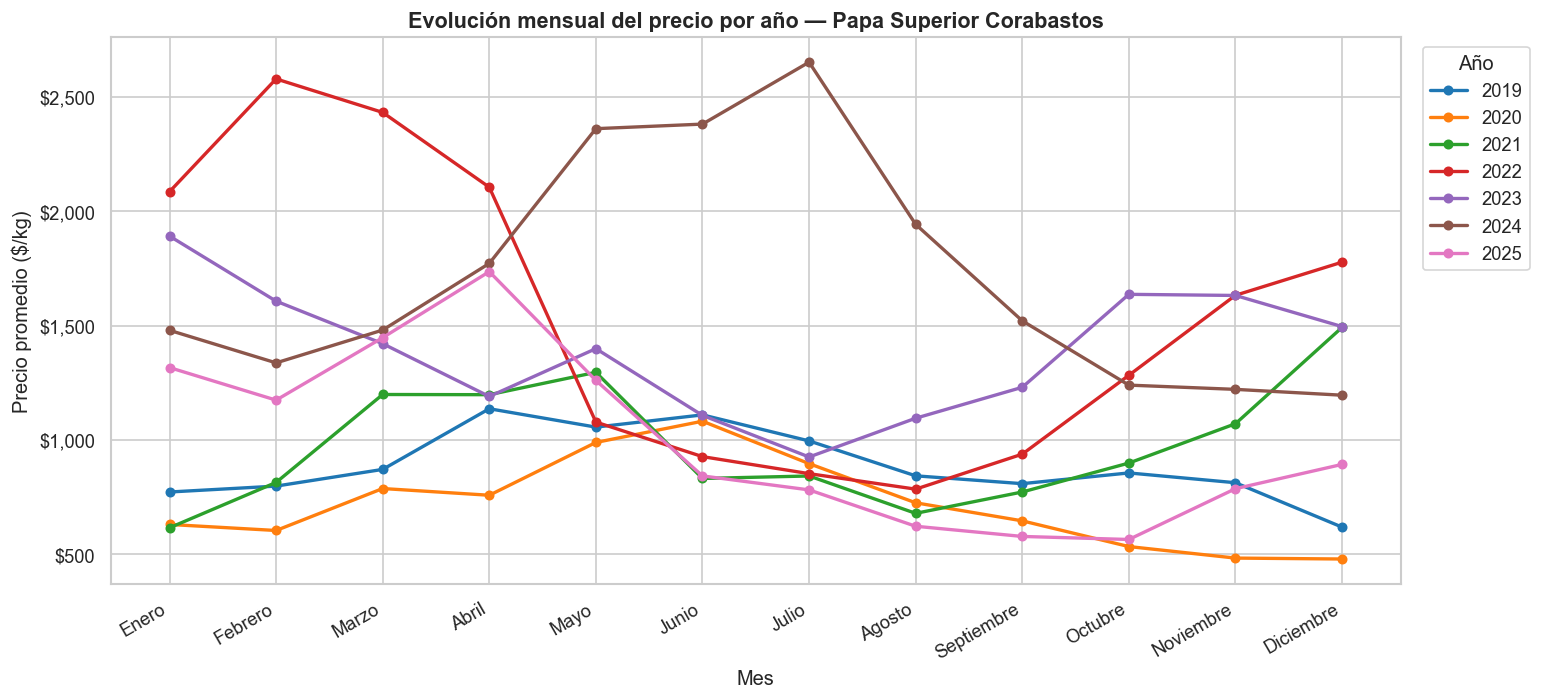

In [15]:
# --- Gráfica: líneas de precio por año superpuestas ---
# Si las líneas siguen patrones similares entre años → hay estacionalidad clara
# Colores distintos para cada año para facilitar la comparación
colores = sns.color_palette('tab10', len(años))

fig, ax = plt.subplots(figsize=(13, 6))

for año, color in zip(años, colores):
    sub  = df_ts[df_ts['Año'] == año]
    vals = sub['precio_promedio'].reindex(
        pd.date_range(f'{año}-01-01', f'{año}-12-01', freq='MS')
    ).values
    ax.plot(meses_orden[:len(vals)], vals,
            marker='o', linewidth=2, label=str(año), color=color, markersize=5)

ax.set_title('Evolución mensual del precio por año — Papa Superior Corabastos',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio promedio ($/kg)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Año', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_lineas_por_año.png'), bbox_inches='tight')
plt.show()

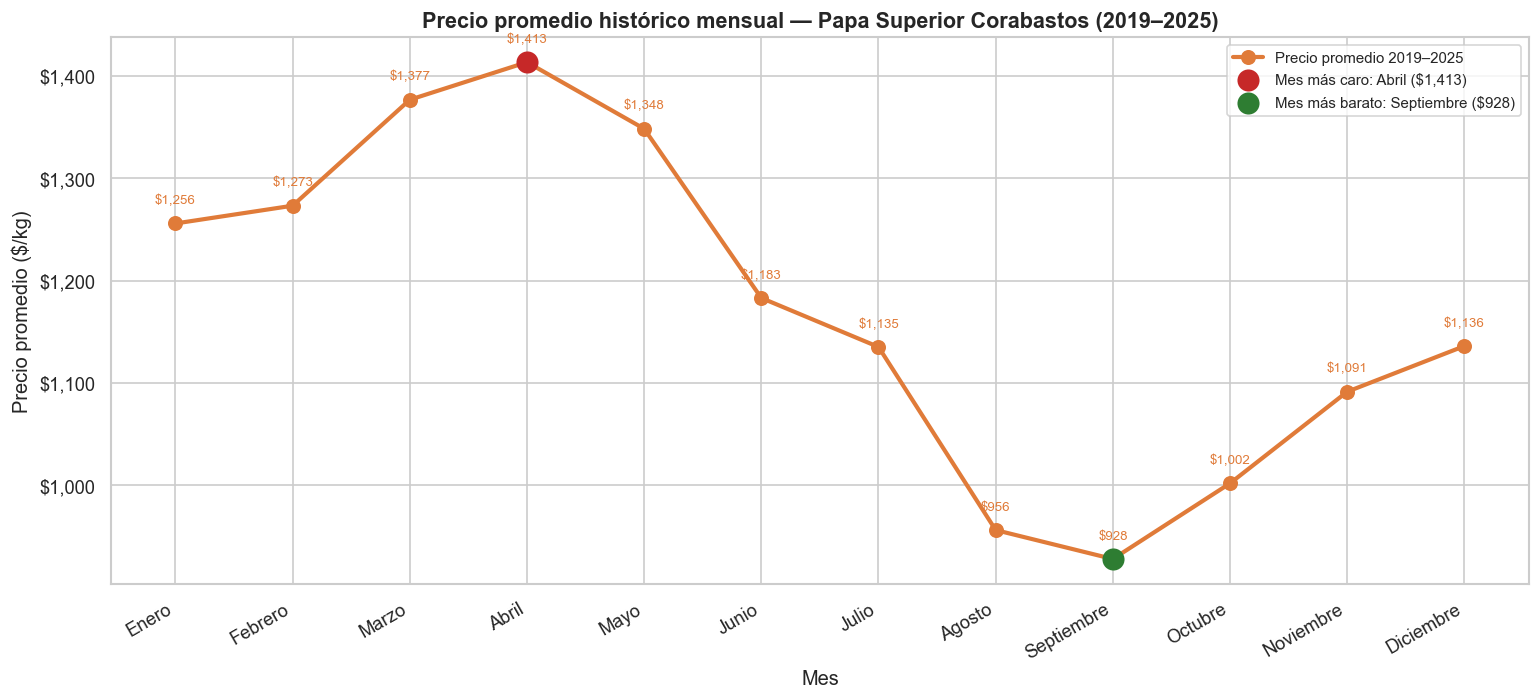

Mes más caro:   Abril ($1,413)
Mes más barato: Septiembre ($928)


In [16]:
# --- Índice estacional: precio promedio por mes (2019-2025) ---
# Promedia el precio de cada mes sobre los 7 años
# Muestra el precio 'típico' de cada mes independientemente del año
estacional_precio = df_ts.groupby('mes_str')['precio_promedio'].mean().reindex(meses_orden)
estacional_abast  = df_ts.groupby('mes_str')['Toneladas'].mean().reindex(meses_orden)

# Gráfica de precio promedio histórico por mes
fig, ax = plt.subplots(figsize=(13, 6))
precio_prom_hist = estacional_precio.values

ax.plot(meses_orden, precio_prom_hist, marker='o', linewidth=2.5,
        color='#E07B39', markersize=8, label='Precio promedio 2019–2025')

for i, (mes, val) in enumerate(zip(meses_orden, precio_prom_hist)):
    ax.annotate(f'${val:,.0f}', xy=(i, val), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=8, color='#E07B39')

idx_max = precio_prom_hist.argmax()
idx_min = precio_prom_hist.argmin()
ax.scatter(meses_orden[idx_max], precio_prom_hist[idx_max], color='#C62828', s=150, zorder=5,
           label=f'Mes más caro: {meses_orden[idx_max]} (${precio_prom_hist[idx_max]:,.0f})')
ax.scatter(meses_orden[idx_min], precio_prom_hist[idx_min], color='#2E7D32', s=150, zorder=5,
           label=f'Mes más barato: {meses_orden[idx_min]} (${precio_prom_hist[idx_min]:,.0f})')

ax.set_title('Precio promedio histórico mensual — Papa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio promedio ($/kg)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_precio_promedio_historico.png'), bbox_inches='tight')
plt.show()

# Guardar índice estacional
estacional_df = pd.DataFrame({
    'mes': meses_orden,
    'precio_promedio_historico': estacional_precio.values.round(2),
    'toneladas_promedio_historico': estacional_abast.values.round(2)
})
estacional_df.to_csv(os.path.join(PROCESSED, 'indice_estacional.csv'), index=False)
print(f"Mes más caro:   {estacional_precio.idxmax()} (${estacional_precio.max():,.0f})")
print(f"Mes más barato: {estacional_precio.idxmin()} (${estacional_precio.min():,.0f})")

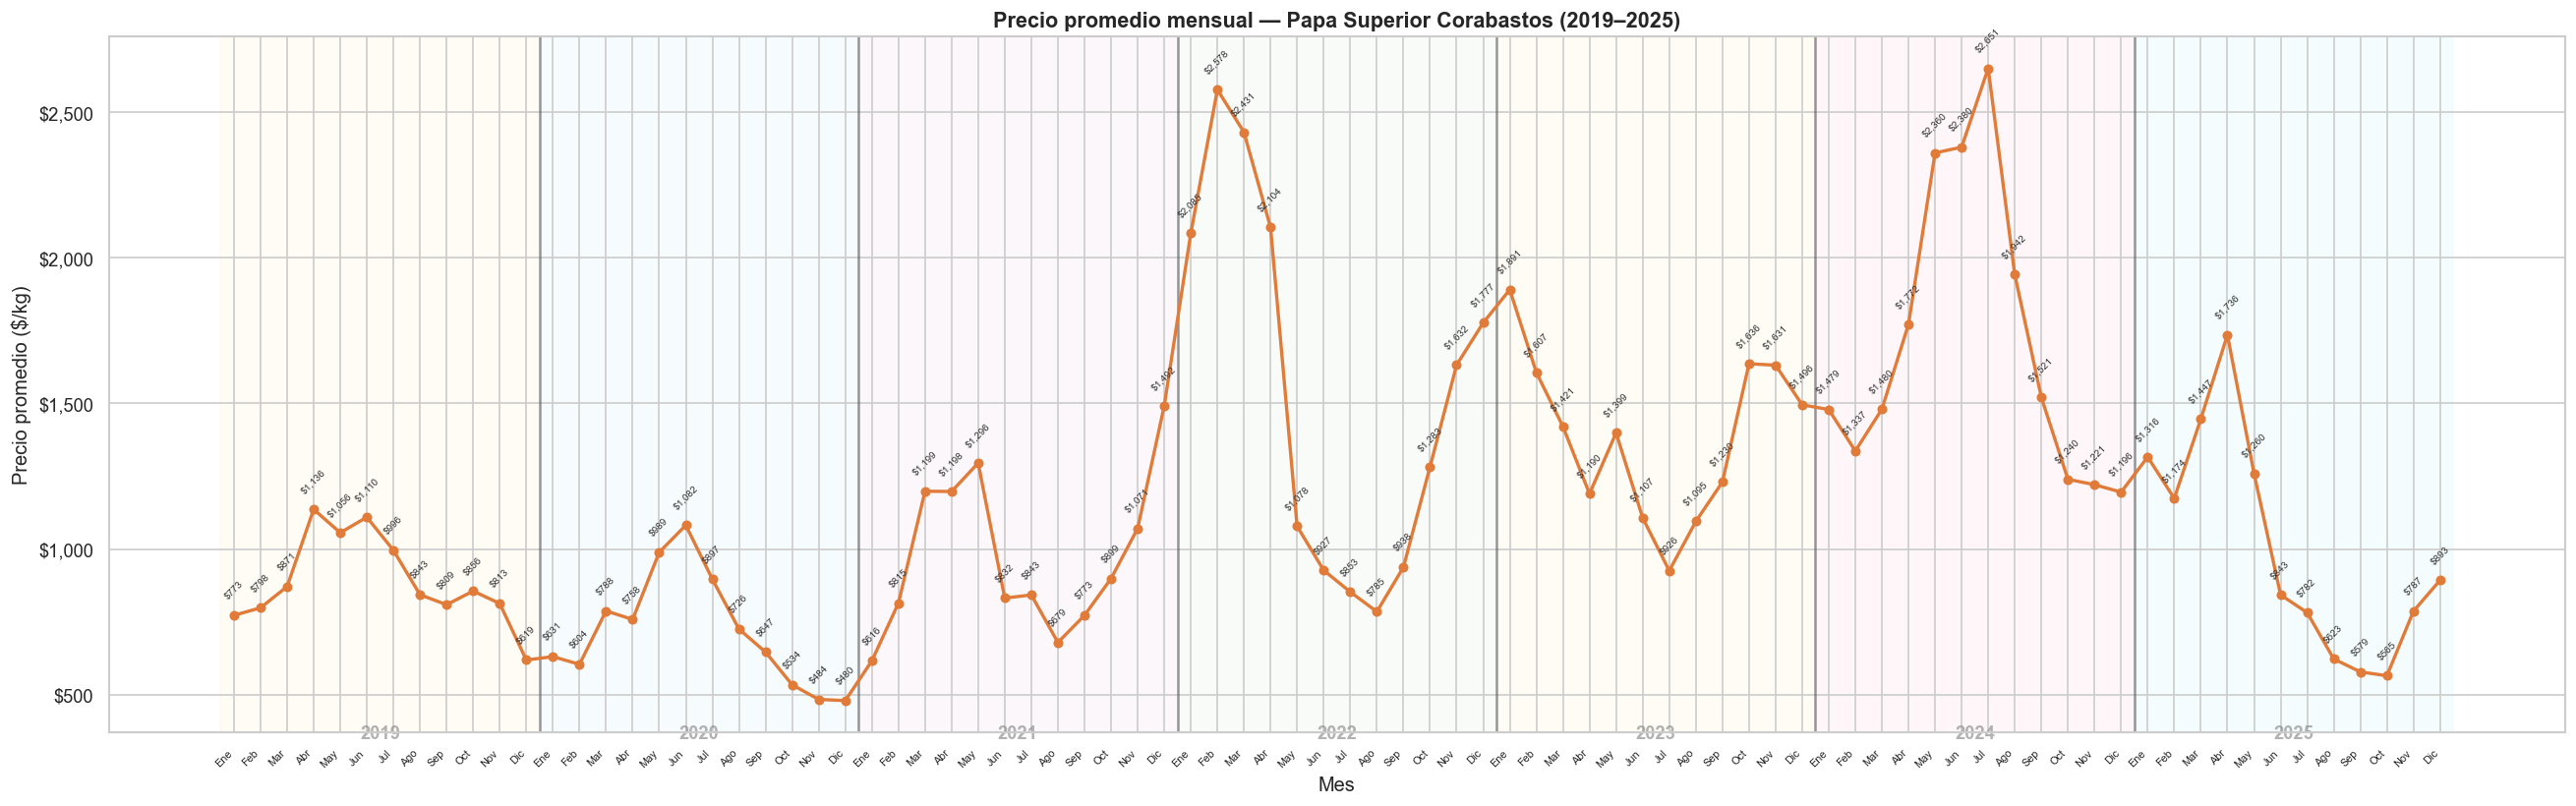

In [17]:
# --- Gráfica 4: Precio mensual histórico con etiquetas ---
# Muestra el precio de cada mes de enero 2019 a diciembre 2025
# Cada año tiene un color de fondo diferente para facilitar la lectura
precio_mensual_hist = df_maestro.sort_values('fecha').reset_index(drop=True)
colores_fondo = ['#FFF3E0', '#E3F2FD', '#F3E5F5', '#E8F5E9', '#FFF8E1', '#FCE4EC', '#E0F7FA']

fig, ax = plt.subplots(figsize=(22, 7))

for i, año in enumerate(range(2019, 2026)):
    idx_inicio = precio_mensual_hist[precio_mensual_hist['Año'] == año].index[0]
    idx_fin    = precio_mensual_hist[precio_mensual_hist['Año'] == año].index[-1]
    ax.axvspan(idx_inicio - 0.5, idx_fin + 0.5, alpha=0.3, color=colores_fondo[i], zorder=0)
    ax.text((idx_inicio + idx_fin) / 2, 350, str(año),
            ha='center', fontsize=11, fontweight='bold', color='gray', alpha=0.6, zorder=1)

ax.plot(range(len(precio_mensual_hist)), precio_mensual_hist['precio_promedio'],
        marker='o', linewidth=2, color='#E07B39', markersize=5, zorder=3)

for i, val in enumerate(precio_mensual_hist['precio_promedio']):
    ax.annotate(f'${val:,.0f}', xy=(i, val), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=6,
                color='#333333', rotation=45, zorder=4)

for año in range(2020, 2026):
    idx = precio_mensual_hist[precio_mensual_hist['Año'] == año].index[0]
    ax.axvline(x=idx - 0.5, color='#555555', linestyle='-', linewidth=1.5, alpha=0.6, zorder=2)

etiquetas = [f"{row['mes'][:3]}" for _, row in precio_mensual_hist.iterrows()]
ax.set_xticks(range(len(precio_mensual_hist)))
ax.set_xticklabels(etiquetas, fontsize=6.5, rotation=45, ha='right')
ax.set_title('Precio promedio mensual — Papa Superior Corabastos (2019–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio promedio ($/kg)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_precio_mensual_etiquetas.png'), bbox_inches='tight')
plt.show()

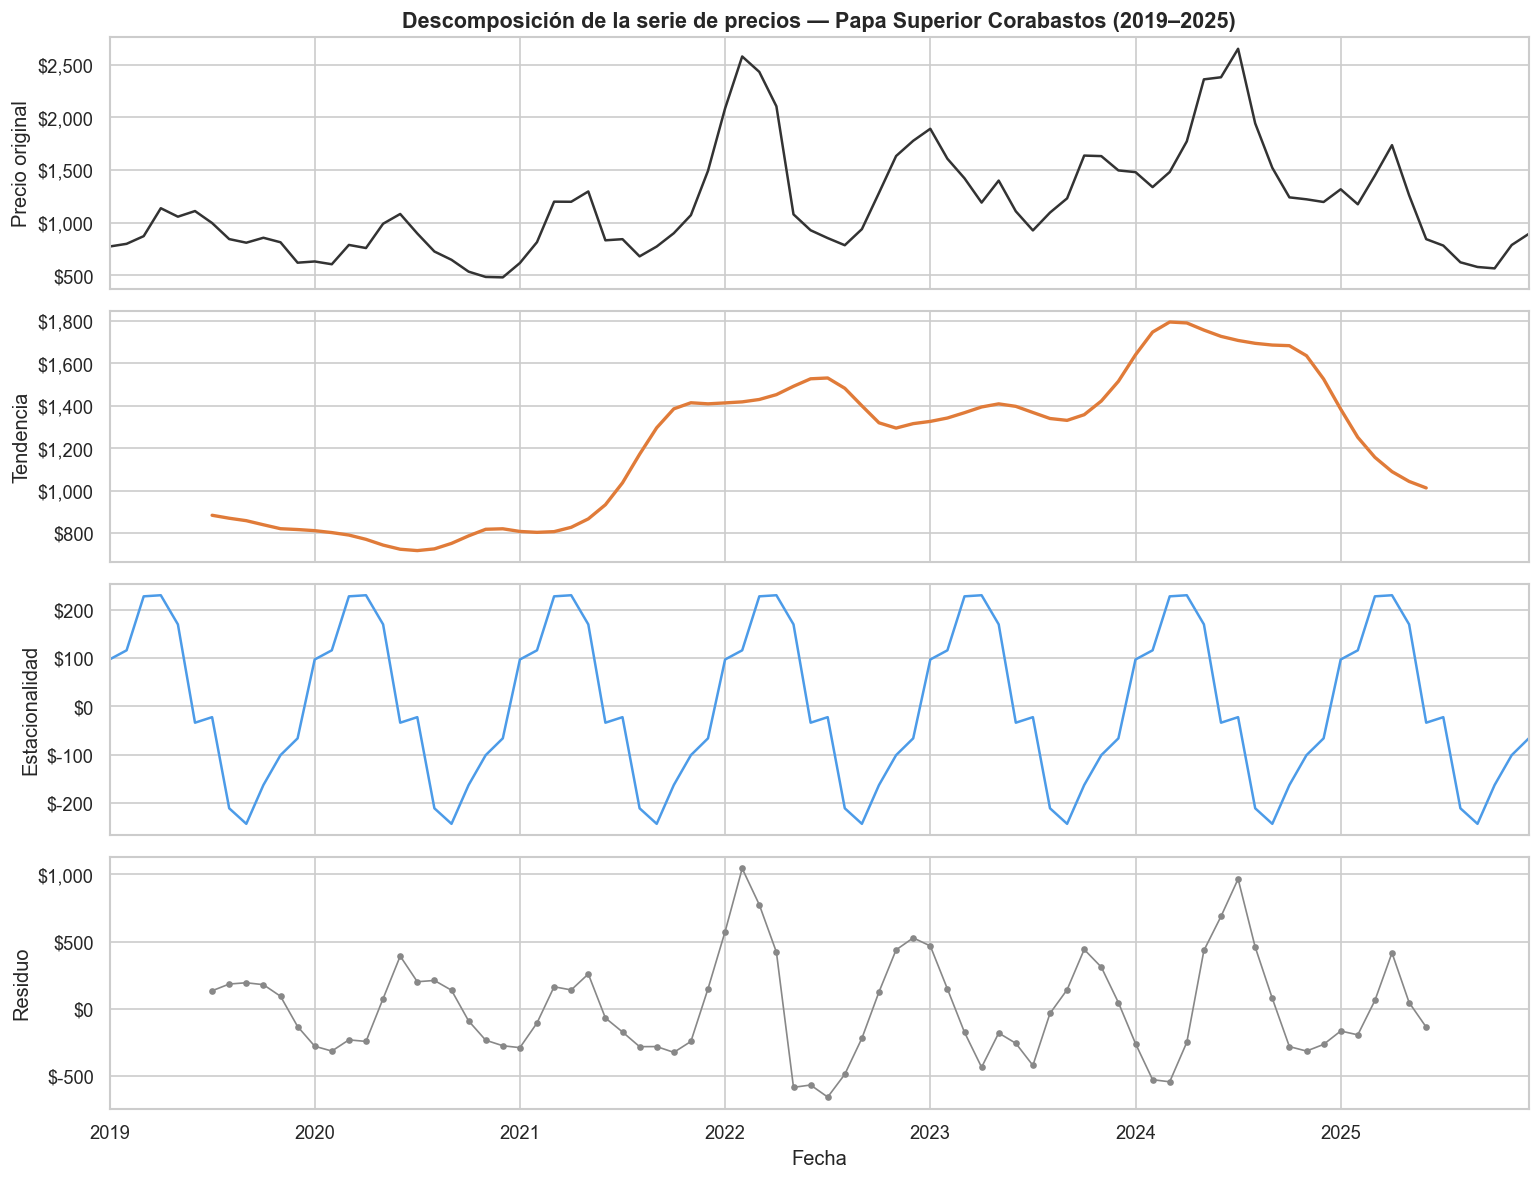

In [18]:
# --- Descomposición estacional de la serie de precios ---
# Separa el precio en 3 partes:
# 1. Tendencia: dirección general a largo plazo (¿el precio sube o baja con el tiempo?)
# 2. Estacionalidad: patrón que se repite cada 12 meses (¿hay meses más caros?)
# 3. Residuo: lo que no explican los dos anteriores (eventos atípicos, shocks)
descomp = seasonal_decompose(
    df_ts['precio_promedio'],
    model='additive',  # precio = tendencia + estacionalidad + residuo
    period=12          # el ciclo es anual (12 meses)
)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

descomp.observed.plot(ax=axes[0], color='#333333', linewidth=1.5)
axes[0].set_ylabel('Precio original')
axes[0].set_title('Descomposición de la serie de precios — Papa Superior Corabastos (2019–2025)',
                  fontsize=13, fontweight='bold')

descomp.trend.plot(ax=axes[1], color='#E07B39', linewidth=2)
axes[1].set_ylabel('Tendencia')

descomp.seasonal.plot(ax=axes[2], color='#4C9BE8', linewidth=1.5)
axes[2].set_ylabel('Estacionalidad')

descomp.resid.plot(ax=axes[3], color='#888888', linewidth=1, marker='o', markersize=3)
axes[3].set_ylabel('Residuo')
axes[3].set_xlabel('Fecha')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_descomposicion_precio.png'), bbox_inches='tight')
plt.show()

### Interpretación — Descomposición de la serie de precios

La descomposición estacional separa el precio en 3 componentes independientes:

---

**Panel 1 — Precio original**  
Muestra el precio real mes a mes sin ningún procesamiento. Se observan dos picos importantes (~$2.500/kg) en 2022 y 2024, y dos valles pronunciados en 2020 (~$480/kg) y finales de 2025 (~$600/kg).

---

**Panel 2 — Tendencia**  
Refleja la dirección general del precio ignorando las fluctuaciones mensuales:
- **2019–2020:** precio bajo y estable (~$800/kg) — impacto del COVID
- **2021–2022:** subida fuerte impulsada por inflación post-pandemia
- **2022–2024:** precio alto sostenido (~$1.400–$1.800/kg)
- **2025:** caída pronunciada hacia ~$1.000/kg

---

**Panel 3 — Estacionalidad**  
Patrón que se repite cada año independientemente de la tendencia:
- **Primer semestre (enero–abril):** precio ~$200/kg por encima de la tendencia
- **Segundo semestre (agosto–septiembre):** precio ~$230/kg por debajo de la tendencia
- El patrón es consistente en todos los años — confirma estacionalidad clara

---

**Panel 4 — Residuo**  
Lo que no explican ni la tendencia ni la estacionalidad — eventos atípicos:
- **2022:** residuo de ~$1.000/kg → crisis por inflación, paro camionero y costos de fertilizantes disparados
- **2024:** residuo de ~$500/kg → nuevo evento atípico de alza de precios

> **Conclusión:** el precio tiene una tendencia alcista sostenida desde 2021, un patrón estacional estable que se repite cada año, y eventos atípicos importantes en 2022 y 2024 que no siguen el comportamiento normal del mercado.

---
## Sección 4 — Preparación de variables para los modelos

Antes de construir los modelos de regresión necesitamos crear algunas variables adicionales:

- **`mes_num`:** convierte el nombre del mes en número (Enero=1, Febrero=2...). Permite que el modelo capture el efecto estacional.
- **`precio_lag1`:** el precio del mes anterior. Captura la **inercia** del precio — si estuvo caro este mes, probablemente sigue caro el siguiente.
- **`precio_real`:** el precio descontada la inflación. Permite separar el efecto del IPC del comportamiento propio del mercado.

> **¿Qué es el lag?** Es simplemente usar el valor pasado de una variable. Si el precio de marzo es $1.200, el lag1 de abril sería $1.200. El modelo usa ese dato para "recordar" cómo estaban los precios.

In [19]:
# --- Preparar variables para los modelos ---

# mes_num: número del mes para capturar estacionalidad en el modelo
df['mes_num'] = pd.to_datetime(df['fecha']).dt.month

# precio_lag1: precio del mes anterior
# Si la papa estuvo cara este mes, probablemente sigue cara el siguiente
df['precio_lag1'] = df['precio_promedio'].shift(1)

# Eliminar filas con NaN (primera fila pierde el lag)
df_model = df.dropna().copy()
y = df_model['precio_promedio']  # variable que queremos explicar/predecir

print(f"Filas disponibles para modelos: {len(df_model)}")
print(f"Período: {df_model['fecha'].min().strftime('%B %Y')} → {df_model['fecha'].max().strftime('%B %Y')}")
print(f"\nVariables disponibles:")
print(f"  - Toneladas (abastecimiento mensual)")
print(f"  - ipc_alimentos (inflación de alimentos %)")
print(f"  - precio_lag1 (precio del mes anterior)")
print(f"  - mes_num (número del mes 1-12)")
print(f"  - fertilizantes, transporte, mano_obra, costo_total (costos en millones $)")

Filas disponibles para modelos: 83
Período: February 2019 → December 2025

Variables disponibles:
  - Toneladas (abastecimiento mensual)
  - ipc_alimentos (inflación de alimentos %)
  - precio_lag1 (precio del mes anterior)
  - mes_num (número del mes 1-12)
  - fertilizantes, transporte, mano_obra, costo_total (costos en millones $)


In [20]:
# --- Función de métricas reutilizable ---
# Esta función calcula las 3 métricas principales para evaluar cada modelo:
# R²   = coeficiente de determinación: qué % de la variación del precio explica el modelo (0 a 1, más alto es mejor)
# MAE  = error absoluto medio: en promedio, cuántos pesos se equivoca el modelo por kg
# RMSE = raíz del error cuadrático medio: similar al MAE pero penaliza más los errores grandes

def metricas(modelo, X, y):
    pred = modelo.predict(X)
    r2   = round(modelo.score(X, y), 4)
    mae  = round(mean_absolute_error(y, pred), 0)
    rmse = round(np.sqrt(mean_squared_error(y, pred)), 0)
    pearson_r, pearson_p = stats.pearsonr(y, pred)
    return {
        'R²'      : r2,
        'MAE'     : mae,
        'RMSE'    : rmse,
        'Pearson r': round(pearson_r, 4),
        'Pearson p': round(pearson_p, 4)
    }

print("✅ Función de métricas lista")
print("\nInterpretación de métricas:")
print("  R² = 0.0 → el modelo no explica nada")
print("  R² = 1.0 → el modelo explica todo perfectamente")
print("  MAE = $200 → el modelo se equivoca en promedio $200 por kg")

✅ Función de métricas lista

Interpretación de métricas:
  R² = 0.0 → el modelo no explica nada
  R² = 1.0 → el modelo explica todo perfectamente
  MAE = $200 → el modelo se equivoca en promedio $200 por kg


---
## Sección 5 — Modelo 1: Solo abastecimiento

### ¿Qué pregunta responde este modelo?
**"Si sé cuántas toneladas de papa llegaron a Corabastos este mes, ¿puedo predecir el precio?"**

Este es el modelo más simple y corresponde directamente a la **hipótesis inicial** del proyecto: a mayor abastecimiento, menor precio.

### Variable usada
- **Toneladas:** total de papa Superior que llegó a Corabastos en el mes

### ¿Qué esperamos encontrar?
Si la hipótesis es correcta, deberíamos ver una **correlación negativa fuerte**: cuando suben las toneladas, baja el precio. El R² debería ser alto.

In [21]:
# --- Modelo 1: Solo abastecimiento ---
X1 = df_model[['Toneladas']]
m1 = LinearRegression().fit(X1, y)
pred_m1 = m1.predict(X1)

met_m1 = metricas(m1, X1, y)

print("=" * 50)
print("MODELO 1 — Solo abastecimiento")
print("=" * 50)
print(f"  R²:        {met_m1['R²']} → el abastecimiento explica solo el {met_m1['R²']*100:.1f}% del precio")
print(f"  MAE:       ${met_m1['MAE']:,.0f}/kg → error promedio de predicción")
print(f"  RMSE:      ${met_m1['RMSE']:,.0f}/kg")
print(f"  Pearson r: {met_m1['Pearson r']} (p={met_m1['Pearson p']})")
print()
print(f"  Coeficiente Toneladas: {m1.coef_[0]:.4f}")
print(f"  → Por cada 1.000 toneladas más → precio {'baja' if m1.coef_[0] < 0 else 'sube'} ${abs(m1.coef_[0]*1000):,.0f}")
print()
print("CONCLUSIÓN: La hipótesis NO se cumple. El abastecimiento casi no explica el precio.")

MODELO 1 — Solo abastecimiento
  R²:        0.0128 → el abastecimiento explica solo el 1.3% del precio
  MAE:       $389/kg → error promedio de predicción
  RMSE:      $501/kg
  Pearson r: 0.1133 (p=0.3079)

  Coeficiente Toneladas: 0.0161
  → Por cada 1.000 toneladas más → precio sube $16

CONCLUSIÓN: La hipótesis NO se cumple. El abastecimiento casi no explica el precio.


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


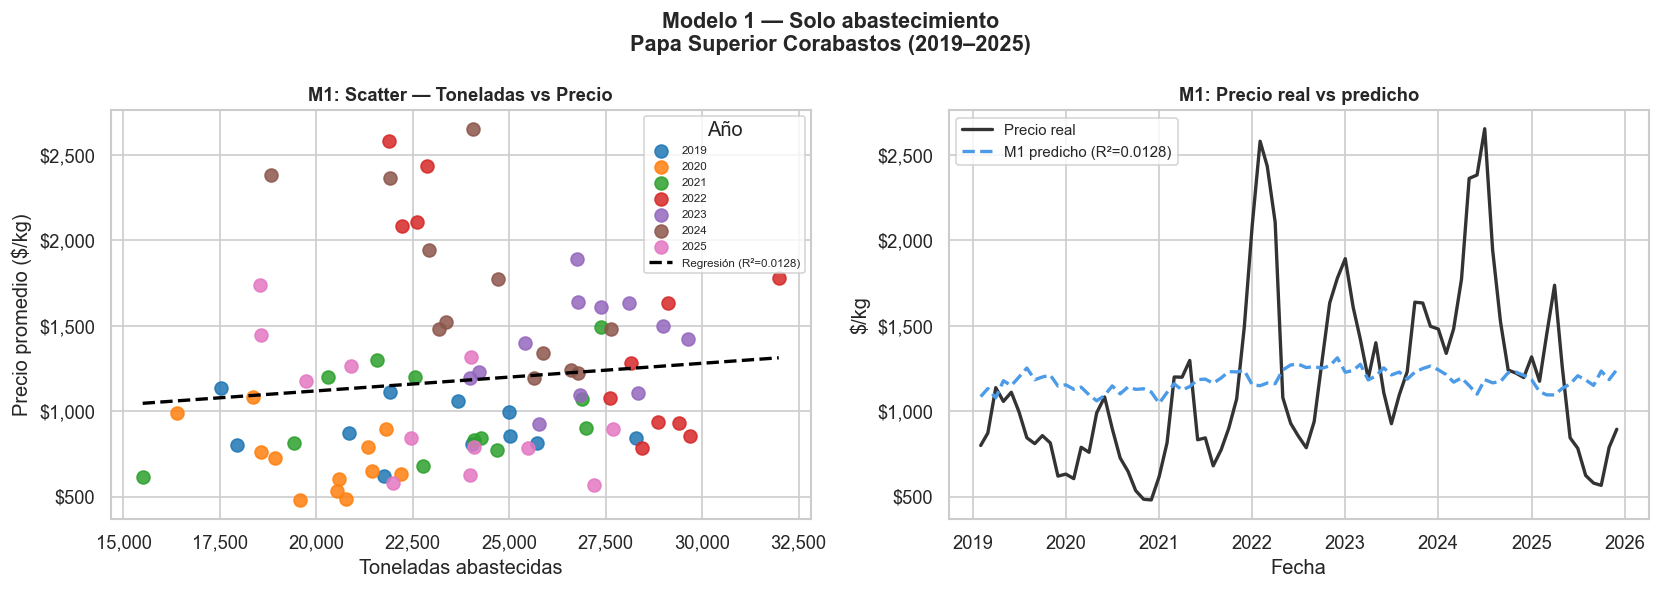

In [22]:
# --- Gráficas Modelo 1 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica izquierda: Scatter con línea de regresión
# Muestra la relación directa entre abastecimiento y precio
colores_año = sns.color_palette('tab10', len(años))
for año, color in zip(años, colores_año):
    sub = df_model[df_model['Año'] == año]
    axes[0].scatter(sub['Toneladas'], sub['precio_promedio'],
                    label=str(año), color=color, s=60, alpha=0.85)

x_range = np.linspace(df_model['Toneladas'].min(), df_model['Toneladas'].max(), 100)
y_pred_line = m1.predict(x_range.reshape(-1, 1))
axes[0].plot(x_range, y_pred_line, color='black', linewidth=2,
             linestyle='--', label=f'Regresión (R²={met_m1["R²"]})')
axes[0].set_title('M1: Scatter — Toneladas vs Precio', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Toneladas abastecidas')
axes[0].set_ylabel('Precio promedio ($/kg)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].legend(title='Año', fontsize=7)

# Gráfica derecha: Precio real vs precio predicho en el tiempo
# Muestra qué tan bien sigue el modelo al precio real
axes[1].plot(df_model['fecha'], y.values, color='#333333', linewidth=2, label='Precio real')
axes[1].plot(df_model['fecha'], pred_m1, color='#4C9BE8', linewidth=2,
             linestyle='--', label=f'M1 predicho (R²={met_m1["R²"]})')
axes[1].set_title('M1: Precio real vs predicho', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('$/kg')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].legend(fontsize=9)

plt.suptitle('Modelo 1 — Solo abastecimiento\nPapa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_m1.png'), bbox_inches='tight')
plt.show()

---
## Sección 6 — Modelo 2: Abastecimiento + IPC

### ¿Qué pregunta responde este modelo?
**"Si el abastecimiento no explica el precio, ¿podría ser la inflación?"**

El IPC de alimentos mide cuánto han subido los precios de los alimentos en general. Si la inflación sube, el precio de la papa también tiende a subir — no porque haya más o menos papa, sino porque todo cuesta más.

### Variables usadas
- **Toneladas:** abastecimiento mensual
- **ipc_alimentos:** variación anual del IPC de alimentos (%)

### Precio real vs precio nominal
Para entender mejor el efecto de la inflación, también calculamos el **precio real** — es decir, el precio quitándole el efecto inflacionario. Si el precio nominal sube pero el real no, significa que la suba fue solo por inflación.

In [23]:
# --- Correlación precio vs IPC (antes del modelo) ---
# ¿Qué tan relacionados están el IPC y el precio de la papa?
pearson_ipc, p_ipc = stats.pearsonr(df_model['ipc_alimentos'], df_model['precio_promedio'])
pearson_ton, p_ton = stats.pearsonr(df_model['Toneladas'], df_model['precio_promedio'])

resumen_corr = pd.DataFrame({
    'Variable'  : ['Toneladas (abastecimiento)', 'IPC alimentos (inflación)'],
    'Pearson r' : [round(pearson_ton, 4), round(pearson_ipc, 4)],
    'Pearson p' : [round(p_ton, 4), round(p_ipc, 4)],
    'Significativo': ['Débil' if abs(pearson_ton) < 0.3 else 'Moderado',
                      'Débil' if abs(pearson_ipc) < 0.3 else 'Moderado']
})

resumen_corr.to_csv(os.path.join(PROCESSED, 'resumen_correlaciones.csv'), index=False)
print("Correlación con el precio nominal:")
print(resumen_corr.to_string(index=False))
print()
print("Interpretación: r cercano a 0 = poca relación. r cercano a ±1 = relación fuerte.")

Correlación con el precio nominal:
                  Variable  Pearson r  Pearson p Significativo
Toneladas (abastecimiento)     0.1133     0.3079         Débil
 IPC alimentos (inflación)     0.2889     0.0081         Débil

Interpretación: r cercano a 0 = poca relación. r cercano a ±1 = relación fuerte.


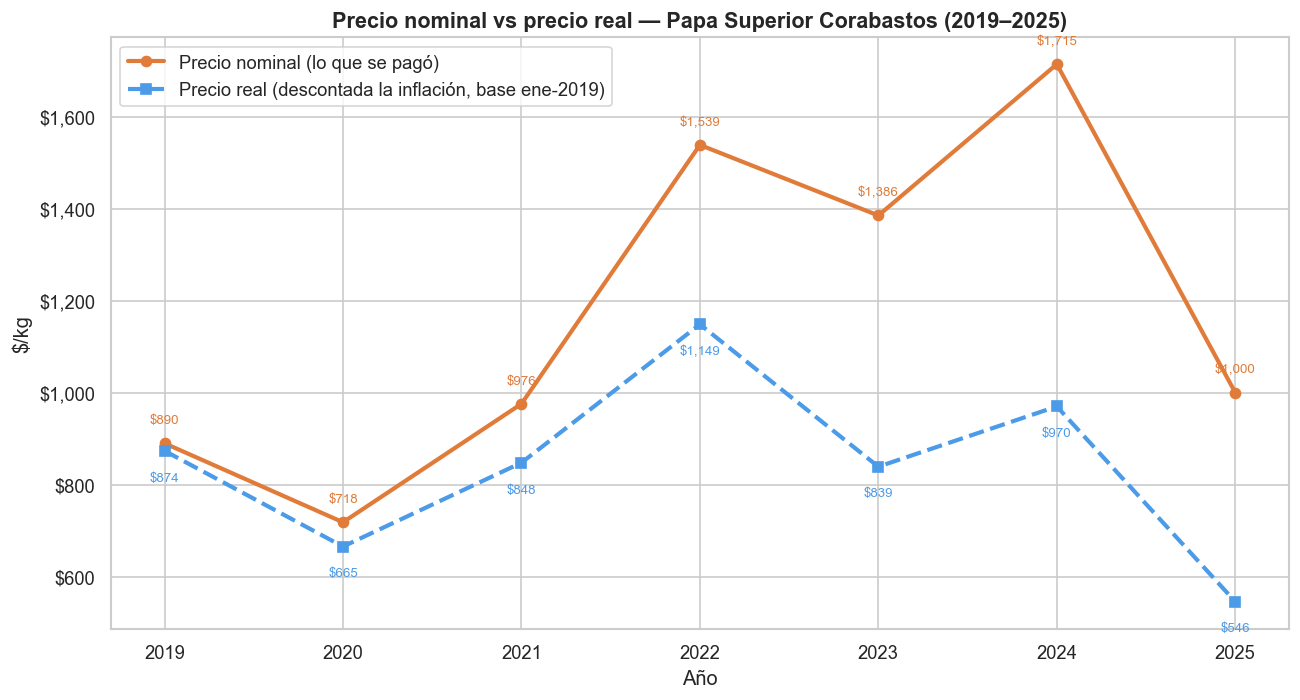

In [24]:
# --- Gráfica: precio nominal vs precio real ---
# La brecha entre las dos líneas = efecto de la inflación
# Cuando la brecha es grande → el precio subió principalmente por inflación
df_anual = df.groupby('Año').agg(
    precio_nominal = ('precio_promedio', 'mean'),
    precio_real    = ('precio_real', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(df_anual['Año'], df_anual['precio_nominal'],
        marker='o', linewidth=2.5, color='#E07B39', label='Precio nominal (lo que se pagó)')
ax.plot(df_anual['Año'], df_anual['precio_real'],
        marker='s', linewidth=2.5, color='#4C9BE8',
        linestyle='--', label='Precio real (descontada la inflación, base ene-2019)')

for _, row in df_anual.iterrows():
    ax.annotate(f"${row['precio_nominal']:,.0f}", xy=(row['Año'], row['precio_nominal']),
                xytext=(0, 12), textcoords='offset points', ha='center', fontsize=8, color='#E07B39')
    ax.annotate(f"${row['precio_real']:,.0f}", xy=(row['Año'], row['precio_real']),
                xytext=(0, -18), textcoords='offset points', ha='center', fontsize=8, color='#4C9BE8')

ax.set_title('Precio nominal vs precio real — Papa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('$/kg')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticks(df_anual['Año'])
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_precio_nominal_vs_real.png'), bbox_inches='tight')
plt.show()

In [25]:
# --- Modelo 2: Abastecimiento + IPC ---
X2 = df_model[['Toneladas', 'ipc_alimentos']]
m2 = LinearRegression().fit(X2, y)
pred_m2 = m2.predict(X2)

met_m2 = metricas(m2, X2, y)

print("=" * 50)
print("MODELO 2 — Abastecimiento + IPC")
print("=" * 50)
print(f"  R²:        {met_m2['R²']} → explica el {met_m2['R²']*100:.1f}% del precio")
print(f"  MAE:       ${met_m2['MAE']:,.0f}/kg")
print(f"  RMSE:      ${met_m2['RMSE']:,.0f}/kg")
print(f"  Pearson r: {met_m2['Pearson r']} (p={met_m2['Pearson p']})")
print()
print("Coeficientes:")
for var, coef in zip(X2.columns, m2.coef_):
    print(f"  {var}: {coef:.4f}")
print()
print("CONCLUSIÓN: Agregar la inflación mejora poco. El modelo aún es débil.")
print("Esto sugiere que hay otras variables más importantes que no hemos incluido.")

MODELO 2 — Abastecimiento + IPC
  R²:        0.0854 → explica el 8.5% del precio
  MAE:       $387/kg
  RMSE:      $483/kg
  Pearson r: 0.2922 (p=0.0074)

Coeficientes:
  Toneladas: -0.0073
  ipc_alimentos: 20.2564

CONCLUSIÓN: Agregar la inflación mejora poco. El modelo aún es débil.
Esto sugiere que hay otras variables más importantes que no hemos incluido.


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


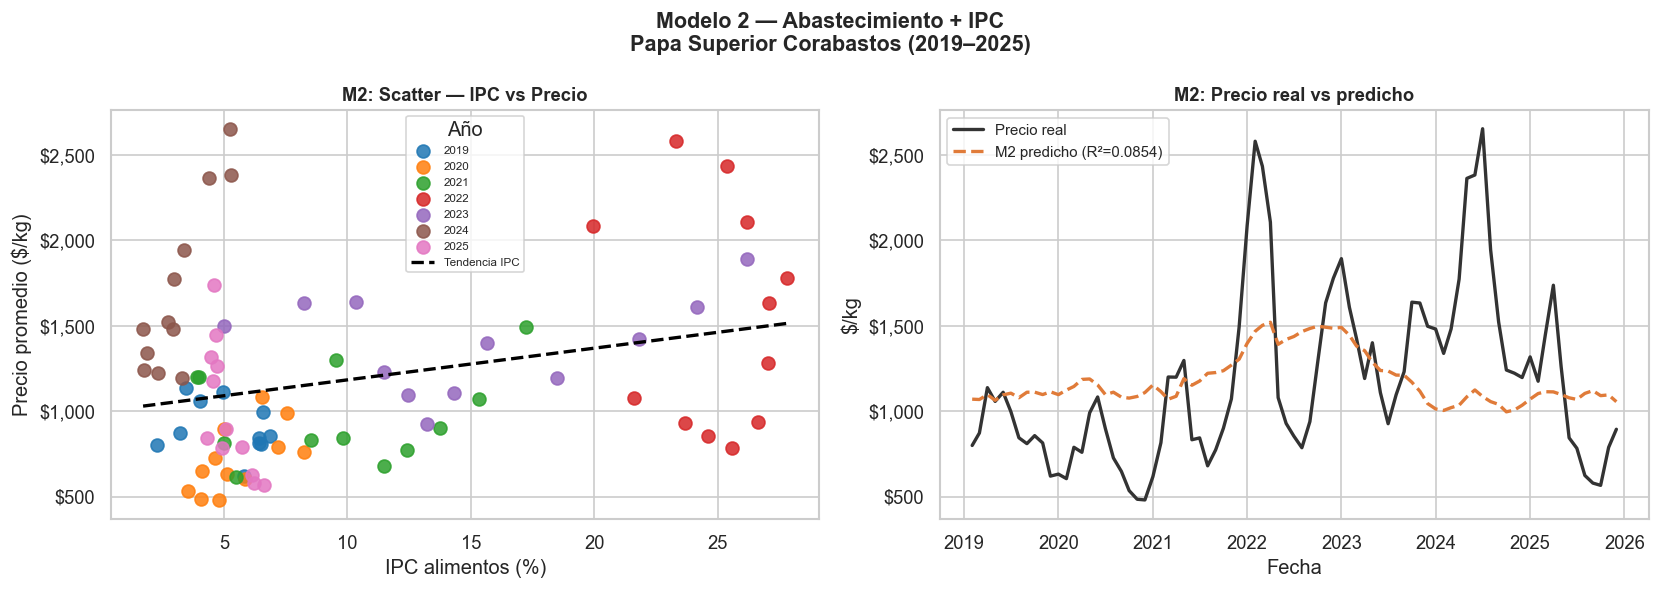

In [26]:
# --- Gráficas Modelo 2 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: IPC vs Precio (la variable más relevante del modelo)
for año, color in zip(años, colores_año):
    sub = df_model[df_model['Año'] == año]
    axes[0].scatter(sub['ipc_alimentos'], sub['precio_promedio'],
                    label=str(año), color=color, s=60, alpha=0.85)

x_ipc = np.linspace(df_model['ipc_alimentos'].min(), df_model['ipc_alimentos'].max(), 100)
# Línea de tendencia usando solo IPC para el scatter
m_ipc = LinearRegression().fit(df_model[['ipc_alimentos']], y)
axes[0].plot(x_ipc, m_ipc.predict(x_ipc.reshape(-1,1)), color='black', linewidth=2,
             linestyle='--', label=f'Tendencia IPC')
axes[0].set_title('M2: Scatter — IPC vs Precio', fontsize=11, fontweight='bold')
axes[0].set_xlabel('IPC alimentos (%)')
axes[0].set_ylabel('Precio promedio ($/kg)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].legend(title='Año', fontsize=7)

# Precio real vs predicho
axes[1].plot(df_model['fecha'], y.values, color='#333333', linewidth=2, label='Precio real')
axes[1].plot(df_model['fecha'], pred_m2, color='#E07B39', linewidth=2,
             linestyle='--', label=f'M2 predicho (R²={met_m2["R²"]})')
axes[1].set_title('M2: Precio real vs predicho', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('$/kg')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].legend(fontsize=9)

plt.suptitle('Modelo 2 — Abastecimiento + IPC\nPapa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_m2.png'), bbox_inches='tight')
plt.show()

---
## Sección 7 — Modelo 3: + Precio anterior + Estacionalidad

### ¿Qué pregunta responde este modelo?
**"¿El precio de la papa de este mes depende de lo que costó el mes pasado?"**

Este modelo introduce dos variables nuevas muy importantes:

1. **precio_lag1** (precio del mes anterior): captura la **inercia** del precio. Los precios no cambian de golpe — si la papa estuvo cara en enero, probablemente sigue cara en febrero.

2. **mes_num** (número del mes): captura la **estacionalidad**. El modelo aprende que abril tiende a ser más caro y septiembre más barato, independientemente de otros factores.

### ¿Por qué este modelo mejora tanto?
El precio del mes anterior tiene un coeficiente de **0.84** — significa que el 84% del precio de este mes está explicado solo por lo que costó el mes pasado. Esto es lo que llamamos **autocorrelación** en series de tiempo.

In [27]:
# --- Modelo 3: Abastecimiento + IPC + lag + estacionalidad ---
X3 = df_model[['Toneladas', 'ipc_alimentos', 'precio_lag1', 'mes_num']]
m3 = LinearRegression().fit(X3, y)
pred_m3 = m3.predict(X3)

met_m3 = metricas(m3, X3, y)

print("=" * 50)
print("MODELO 3 — Abastecimiento + IPC + lag + estacionalidad")
print("=" * 50)
print(f"  R²:        {met_m3['R²']} → explica el {met_m3['R²']*100:.1f}% del precio")
print(f"  MAE:       ${met_m3['MAE']:,.0f}/kg")
print(f"  RMSE:      ${met_m3['RMSE']:,.0f}/kg")
print(f"  Pearson r: {met_m3['Pearson r']} (p={met_m3['Pearson p']})")
print()
coef_m3 = pd.DataFrame({
    'Variable'       : X3.columns.tolist(),
    'Coeficiente'    : m3.coef_.round(4),
    'En palabras simples': [
        f'Por cada 1.000 ton más → precio baja ${abs(m3.coef_[0])*1000:,.0f}',
        f'Por cada 1% más de inflación → precio sube ${m3.coef_[1]:,.1f}',
        f'Por cada $1 más el mes pasado → precio sube ${m3.coef_[2]:,.2f} este mes',
        f'Por cada mes avanzado → precio baja ${abs(m3.coef_[3]):,.1f}'
    ]
})
print(coef_m3.to_string(index=False))
print()
print("CONCLUSIÓN: El precio del mes anterior es la variable más importante.")
print("El precio de la papa tiene mucha inercia.")

MODELO 3 — Abastecimiento + IPC + lag + estacionalidad
  R²:        0.7599 → explica el 76.0% del precio
  MAE:       $188/kg
  RMSE:      $247/kg
  Pearson r: 0.8717 (p=0.0)

     Variable  Coeficiente                                        En palabras simples
    Toneladas      -0.0100                   Por cada 1.000 ton más → precio baja $10
ipc_alimentos       6.6744            Por cada 1% más de inflación → precio sube $6.7
  precio_lag1       0.8415 Por cada $1 más el mes pasado → precio sube $0.84 este mes
      mes_num      -4.8780                   Por cada mes avanzado → precio baja $4.9

CONCLUSIÓN: El precio del mes anterior es la variable más importante.
El precio de la papa tiene mucha inercia.


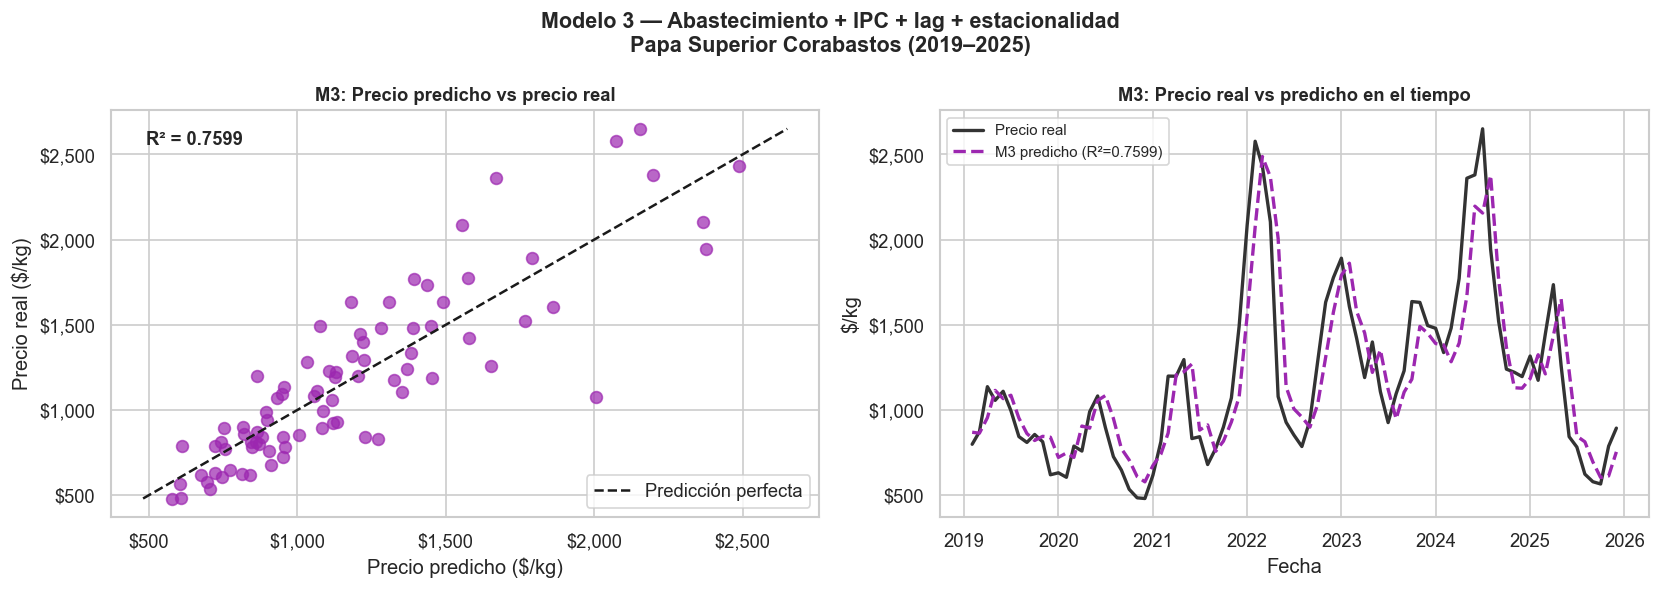

In [28]:
# --- Gráficas Modelo 3 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: precio predicho vs precio real (para modelos multivariados)
# Si el modelo fuera perfecto, todos los puntos estarían sobre la diagonal
axes[0].scatter(pred_m3, y.values, alpha=0.7, color='#9C27B0', s=50)
lims = [min(pred_m3.min(), y.min()), max(pred_m3.max(), y.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title('M3: Precio predicho vs precio real', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Precio predicho ($/kg)')
axes[0].set_ylabel('Precio real ($/kg)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].legend()
axes[0].text(0.05, 0.95, f'R² = {met_m3["R²"]}', transform=axes[0].transAxes,
             fontsize=11, fontweight='bold', va='top')

# Precio real vs predicho en el tiempo
axes[1].plot(df_model['fecha'], y.values, color='#333333', linewidth=2, label='Precio real')
axes[1].plot(df_model['fecha'], pred_m3, color='#9C27B0', linewidth=2,
             linestyle='--', label=f'M3 predicho (R²={met_m3["R²"]})')
axes[1].set_title('M3: Precio real vs predicho en el tiempo', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('$/kg')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].legend(fontsize=9)

plt.suptitle('Modelo 3 — Abastecimiento + IPC + lag + estacionalidad\nPapa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_m3.png'), bbox_inches='tight')
plt.show()

---
## Sección 8 — Modelo 4: + Costos de producción

### ¿Qué pregunta responde este modelo?
**"¿Los costos de producción en finca (fertilizantes, transporte, mano de obra) afectan el precio en Corabastos?"**

La lógica económica es simple: si los insumos que necesita el agricultor se encarecen, ese costo se traslada al precio de venta. Los datos de costos provienen del **Observatorio FNFP** para Boyacá y Cundinamarca — los departamentos que más papa aportan a Corabastos.

### Variables usadas
- **Toneladas:** abastecimiento mensual
- **ipc_alimentos:** inflación de alimentos
- **fertilizantes:** costo mensual en fertilizantes (millones $)
- **transporte:** costo mensual de transporte (millones $)
- **mano_obra:** costo mensual de mano de obra (millones $)
- **costo_total:** suma de todos los rubros de costo (millones $)

In [29]:
# --- Modelo 4: Abastecimiento + IPC + costos de producción ---
X4 = df_model[['Toneladas', 'ipc_alimentos', 'fertilizantes', 'transporte',
               'mano_obra', 'costo_total']]
m4 = LinearRegression().fit(X4, y)
pred_m4 = m4.predict(X4)

met_m4 = metricas(m4, X4, y)

print("=" * 50)
print("MODELO 4 — Abastecimiento + IPC + Costos")
print("=" * 50)
print(f"  R²:        {met_m4['R²']} → explica el {met_m4['R²']*100:.1f}% del precio")
print(f"  MAE:       ${met_m4['MAE']:,.0f}/kg")
print(f"  RMSE:      ${met_m4['RMSE']:,.0f}/kg")
print(f"  Pearson r: {met_m4['Pearson r']} (p={met_m4['Pearson p']})")
print()
coef_m4 = pd.DataFrame({
    'Variable'    : X4.columns.tolist(),
    'Coeficiente' : m4.coef_.round(4),
    'En palabras simples': [
        'Por cada 1.000 ton más → precio baja $34',
        'Por cada 1% más de inflación → precio sube $9.6',
        'Por cada millón más en fertilizantes → precio baja $151',
        'Por cada millón más en transporte → precio baja $506',
        'Por cada millón más en mano de obra → precio baja $297',
        'Por cada millón más en costo total → precio sube $93'
    ]
})
print(coef_m4.to_string(index=False))
print()
print("CONCLUSIÓN: Los costos solos mejoran poco sin el lag. El precio pasado sigue siendo clave.")

MODELO 4 — Abastecimiento + IPC + Costos
  R²:        0.6856 → explica el 68.6% del precio
  MAE:       $220/kg
  RMSE:      $283/kg
  Pearson r: 0.828 (p=0.0)

     Variable  Coeficiente                                     En palabras simples
    Toneladas      -0.0336                Por cada 1.000 ton más → precio baja $34
ipc_alimentos       9.5749         Por cada 1% más de inflación → precio sube $9.6
fertilizantes    -150.7209 Por cada millón más en fertilizantes → precio baja $151
   transporte    -506.4073    Por cada millón más en transporte → precio baja $506
    mano_obra    -296.9128  Por cada millón más en mano de obra → precio baja $297
  costo_total      92.9256    Por cada millón más en costo total → precio sube $93

CONCLUSIÓN: Los costos solos mejoran poco sin el lag. El precio pasado sigue siendo clave.


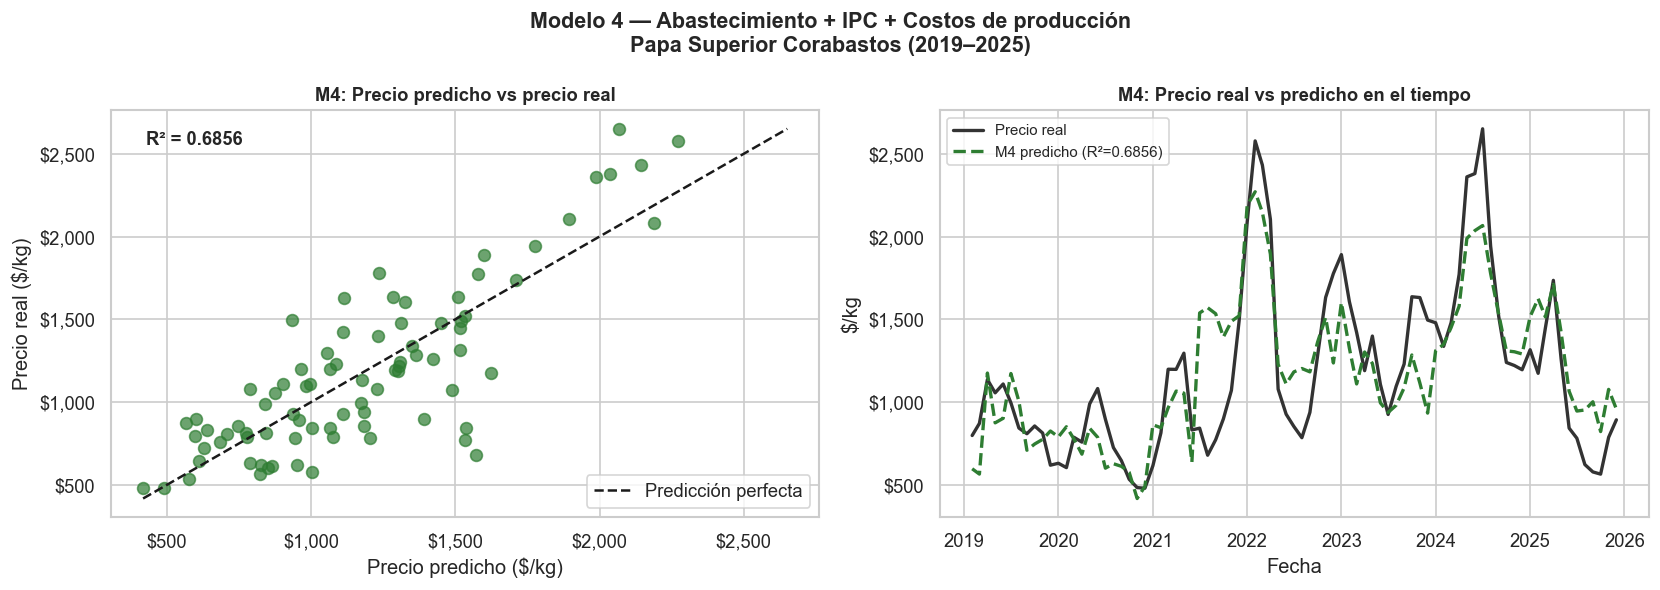

In [30]:
# --- Gráficas Modelo 4 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: precio predicho vs precio real
axes[0].scatter(pred_m4, y.values, alpha=0.7, color='#2E7D32', s=50)
lims = [min(pred_m4.min(), y.min()), max(pred_m4.max(), y.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title('M4: Precio predicho vs precio real', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Precio predicho ($/kg)')
axes[0].set_ylabel('Precio real ($/kg)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].legend()
axes[0].text(0.05, 0.95, f'R² = {met_m4["R²"]}', transform=axes[0].transAxes,
             fontsize=11, fontweight='bold', va='top')

# Precio real vs predicho en el tiempo
axes[1].plot(df_model['fecha'], y.values, color='#333333', linewidth=2, label='Precio real')
axes[1].plot(df_model['fecha'], pred_m4, color='#2E7D32', linewidth=2,
             linestyle='--', label=f'M4 predicho (R²={met_m4["R²"]})')
axes[1].set_title('M4: Precio real vs predicho en el tiempo', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('$/kg')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].legend(fontsize=9)

plt.suptitle('Modelo 4 — Abastecimiento + IPC + Costos de producción\nPapa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_m4.png'), bbox_inches='tight')
plt.show()

---
## Sección 9 — Modelo 5: Modelo completo

### ¿Qué pregunta responde este modelo?
**"¿Qué pasa si combinamos todas las variables que hemos encontrado?"**

Este es el modelo más completo del proyecto. Combina:
- El **abastecimiento** (hipótesis original)
- La **inflación** (IPC alimentos)
- Los **costos de producción** (fertilizantes, transporte, mano de obra)
- La **inercia del precio** (precio del mes anterior)
- La **estacionalidad** (número del mes)

### ¿Por qué es el mejor modelo?
Al combinar la inercia del precio con los costos de producción y la estacionalidad, el modelo captura múltiples dimensiones del comportamiento del precio. El R² de **0.85** significa que con estas 8 variables podemos explicar el 85% de las variaciones del precio.

In [31]:
# --- Modelo 5: Modelo completo ---
X5 = df_model[['Toneladas', 'ipc_alimentos', 'fertilizantes', 'transporte',
               'mano_obra', 'costo_total', 'precio_lag1', 'mes_num']]
m5 = LinearRegression().fit(X5, y)
pred_m5 = m5.predict(X5)

met_m5 = metricas(m5, X5, y)

print("=" * 50)
print("MODELO 5 — Modelo completo")
print("=" * 50)
print(f"  R²:        {met_m5['R²']} → explica el {met_m5['R²']*100:.1f}% del precio")
print(f"  MAE:       ${met_m5['MAE']:,.0f}/kg")
print(f"  RMSE:      ${met_m5['RMSE']:,.0f}/kg")
print(f"  Pearson r: {met_m5['Pearson r']} (p={met_m5['Pearson p']})")
print()
coef_m5 = pd.DataFrame({
    'Variable'   : X5.columns.tolist(),
    'Coeficiente': m5.coef_.round(4)
})
print(coef_m5.to_string(index=False))
print()
print("CONCLUSIÓN: El modelo completo es el mejor con R²=0.85.")
print("El precio del mes anterior + estacionalidad + costos explican el 85% del precio.")

MODELO 5 — Modelo completo
  R²:        0.8525 → explica el 85.2% del precio
  MAE:       $150/kg
  RMSE:      $194/kg
  Pearson r: 0.9233 (p=0.0)

     Variable  Coeficiente
    Toneladas      -0.0139
ipc_alimentos      24.3803
fertilizantes    -142.1060
   transporte      66.6895
    mano_obra    -123.1361
  costo_total      44.5972
  precio_lag1       0.6100
      mes_num       0.2932

CONCLUSIÓN: El modelo completo es el mejor con R²=0.85.
El precio del mes anterior + estacionalidad + costos explican el 85% del precio.


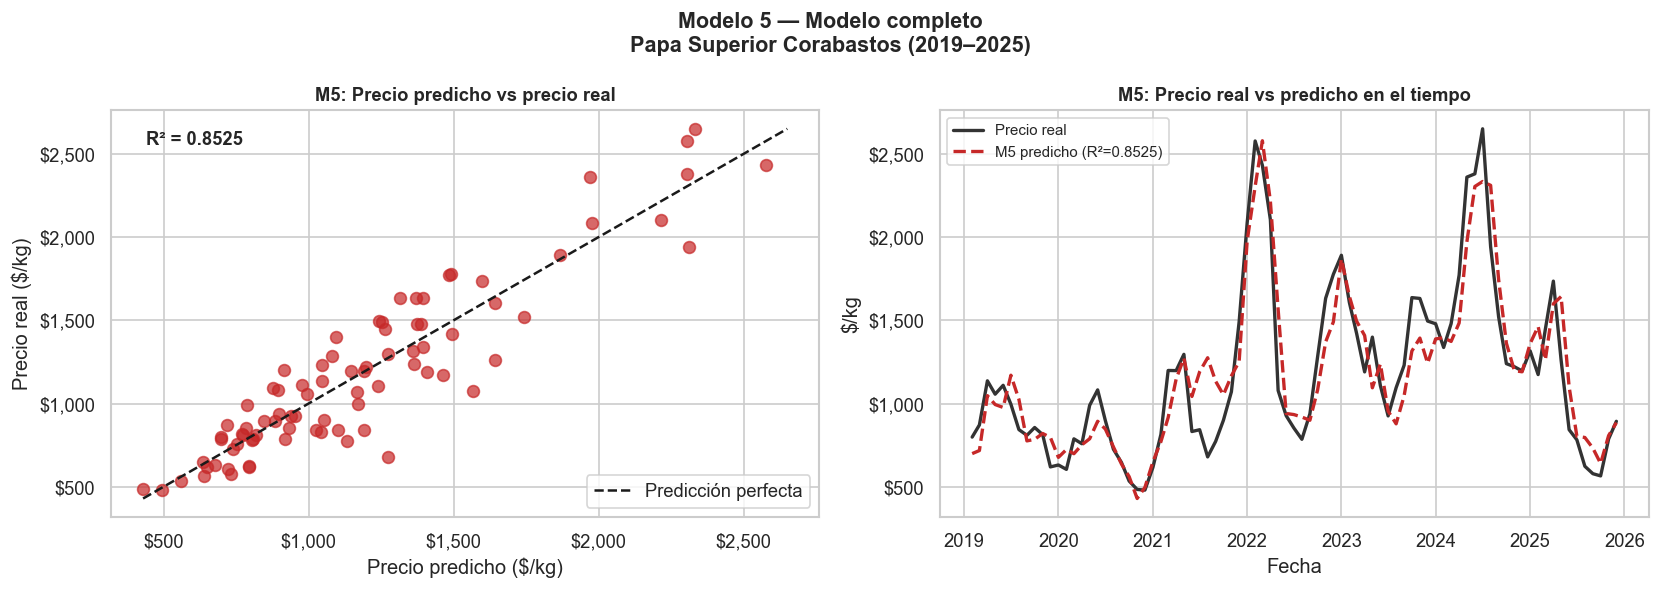

In [32]:
# --- Gráficas Modelo 5 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: precio predicho vs precio real
axes[0].scatter(pred_m5, y.values, alpha=0.7, color='#C62828', s=50)
lims = [min(pred_m5.min(), y.min()), max(pred_m5.max(), y.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title('M5: Precio predicho vs precio real', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Precio predicho ($/kg)')
axes[0].set_ylabel('Precio real ($/kg)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].legend()
axes[0].text(0.05, 0.95, f'R² = {met_m5["R²"]}', transform=axes[0].transAxes,
             fontsize=11, fontweight='bold', va='top')

# Precio real vs predicho en el tiempo
axes[1].plot(df_model['fecha'], y.values, color='#333333', linewidth=2, label='Precio real')
axes[1].plot(df_model['fecha'], pred_m5, color='#C62828', linewidth=2,
             linestyle='--', label=f'M5 predicho (R²={met_m5["R²"]})')
axes[1].set_title('M5: Precio real vs predicho en el tiempo', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('$/kg')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].legend(fontsize=9)

plt.suptitle('Modelo 5 — Modelo completo\nPapa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_m5.png'), bbox_inches='tight')
plt.show()

In [33]:
# --- Tabla comparativa final de todos los modelos ---
# Evaluar todos los modelos sobre el mismo conjunto de filas (df_model con costos)
X1_c = df_model[['Toneladas']]
X2_c = df_model[['Toneladas', 'ipc_alimentos']]
X3_c = df_model[['Toneladas', 'ipc_alimentos', 'precio_lag1', 'mes_num']]

modelos_lista = [
    ('M1: solo abastecimiento',                      m1, X1_c),
    ('M2: abastecimiento + IPC',                     m2, X2_c),
    ('M3: + lag + estacionalidad',                   m3, X3_c),
    ('M4: + costos de producción',                   m4, X4),
    ('M5: completo (costos + lag + estacionalidad)', m5, X5),
]

resumen_final = pd.DataFrame({
    'Modelo' : [n for n,_,_ in modelos_lista],
    'R²'     : [round(m.score(X, y), 4) for _,m,X in modelos_lista],
    'MAE'    : [round(mean_absolute_error(y, m.predict(X)), 0) for _,m,X in modelos_lista],
    'RMSE'   : [round(np.sqrt(mean_squared_error(y, m.predict(X))), 0) for _,m,X in modelos_lista]
})

resumen_final.to_csv(os.path.join(PROCESSED, 'resumen_modelos_completo.csv'), index=False)
print("Comparación final de todos los modelos:")
print(resumen_final.to_string(index=False))

Comparación final de todos los modelos:
                                      Modelo     R²   MAE  RMSE
                     M1: solo abastecimiento 0.0128 389.0 501.0
                    M2: abastecimiento + IPC 0.0854 387.0 483.0
                  M3: + lag + estacionalidad 0.7599 188.0 247.0
                  M4: + costos de producción 0.6856 220.0 283.0
M5: completo (costos + lag + estacionalidad) 0.8525 150.0 194.0


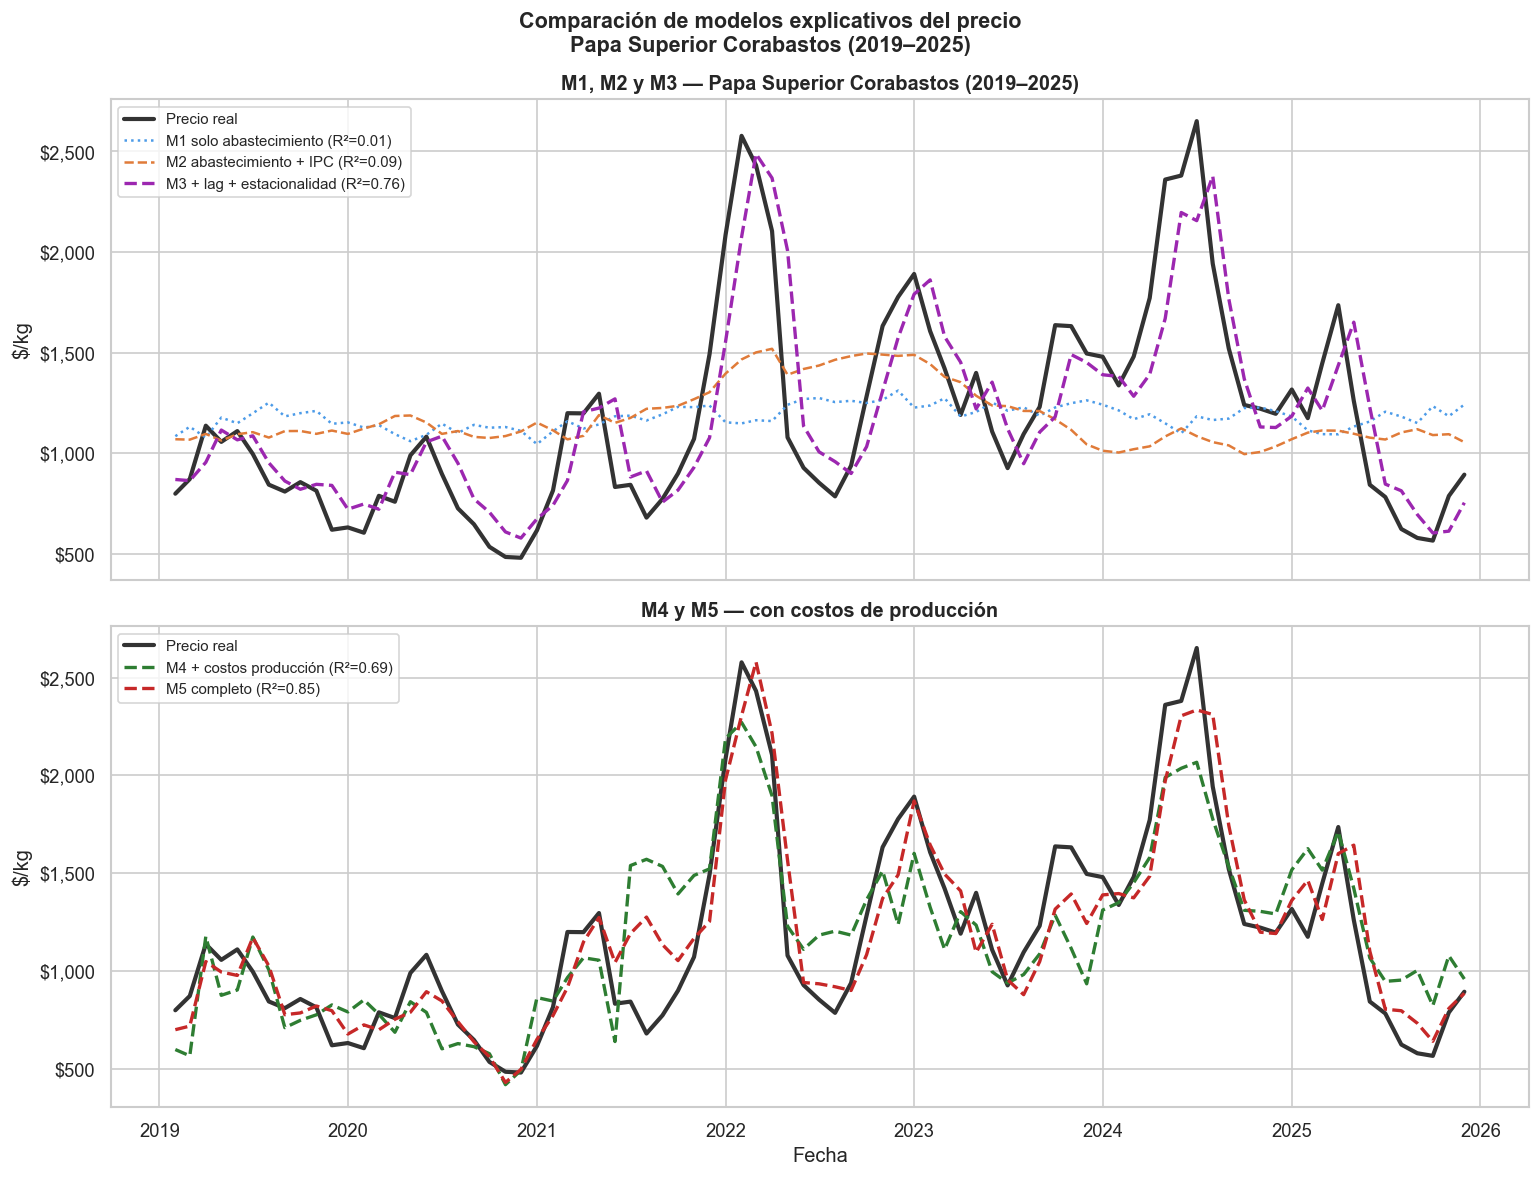

In [34]:
# --- Gráfica comparativa: todos los modelos en 2 paneles ---
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

# Panel superior: M1, M2 y M3
axes[0].plot(df_model['fecha'], y.values, color='#333333', linewidth=2.5, label='Precio real')
axes[0].plot(df_model['fecha'], m1.predict(X1_c), color='#4C9BE8', linewidth=1.5,
             linestyle=':', label=f'M1 solo abastecimiento (R²={round(m1.score(X1_c,y),2)})')
axes[0].plot(df_model['fecha'], m2.predict(X2_c), color='#E07B39', linewidth=1.5,
             linestyle='--', label=f'M2 abastecimiento + IPC (R²={round(m2.score(X2_c,y),2)})')
axes[0].plot(df_model['fecha'], m3.predict(X3_c), color='#9C27B0', linewidth=2,
             linestyle='--', label=f'M3 + lag + estacionalidad (R²={round(m3.score(X3_c,y),2)})')
axes[0].set_title('M1, M2 y M3 — Papa Superior Corabastos (2019–2025)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('$/kg')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].legend(loc='upper left', fontsize=9)

# Panel inferior: M4 y M5
axes[1].plot(df_model['fecha'], y.values, color='#333333', linewidth=2.5, label='Precio real')
axes[1].plot(df_model['fecha'], pred_m4, color='#2E7D32', linewidth=2,
             linestyle='--', label=f'M4 + costos producción (R²={round(m4.score(X4,y),2)})')
axes[1].plot(df_model['fecha'], pred_m5, color='#C62828', linewidth=2,
             linestyle='--', label=f'M5 completo (R²={round(m5.score(X5,y),2)})')
axes[1].set_title('M4 y M5 — con costos de producción', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('$/kg')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].legend(loc='upper left', fontsize=9)

plt.suptitle('Comparación de modelos explicativos del precio\nPapa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_todos_los_modelos.png'), bbox_inches='tight')
plt.show()

In [35]:
# --- Guardar predicciones de todos los modelos ---
df_model['precio_predicho_m1'] = m1.predict(X1_c)
df_model['precio_predicho_m2'] = m2.predict(X2_c)
df_model['precio_predicho_m3'] = m3.predict(X3_c)
df_model['precio_predicho_m4'] = pred_m4
df_model['precio_predicho_m5'] = pred_m5

df_model[['Año','mes','fecha','precio_promedio',
          'precio_predicho_m1','precio_predicho_m2','precio_predicho_m3',
          'precio_predicho_m4','precio_predicho_m5']].to_csv(
    os.path.join(PROCESSED, 'predicciones_todos_modelos.csv'), index=False
)

print("✅ Predicciones de todos los modelos guardadas")

✅ Predicciones de todos los modelos guardadas


---
## Sección 10 — Comparación Corabastos vs Coomproriente (2024–2025)

Para enriquecer el análisis, comparamos el comportamiento de la papa Superior en dos centrales mayoristas:

- **Corabastos (Bogotá):** la central mayorista más grande de Colombia, abastece principalmente el centro del país
- **Coomproriente (Boyacá):** central mayorista del oriente colombiano, ubicada en la zona productora

Para el precio de Coomproriente usamos **Duitama** como referencia — ciudad de Boyacá con datos de precio del SIPSA que representa bien la zona de influencia de Coomproriente.

> **¿Por qué comparar?** Las diferencias en precio y abastecimiento entre centrales permiten entender cómo fluye la oferta desde las zonas productoras hacia los mercados de consumo.

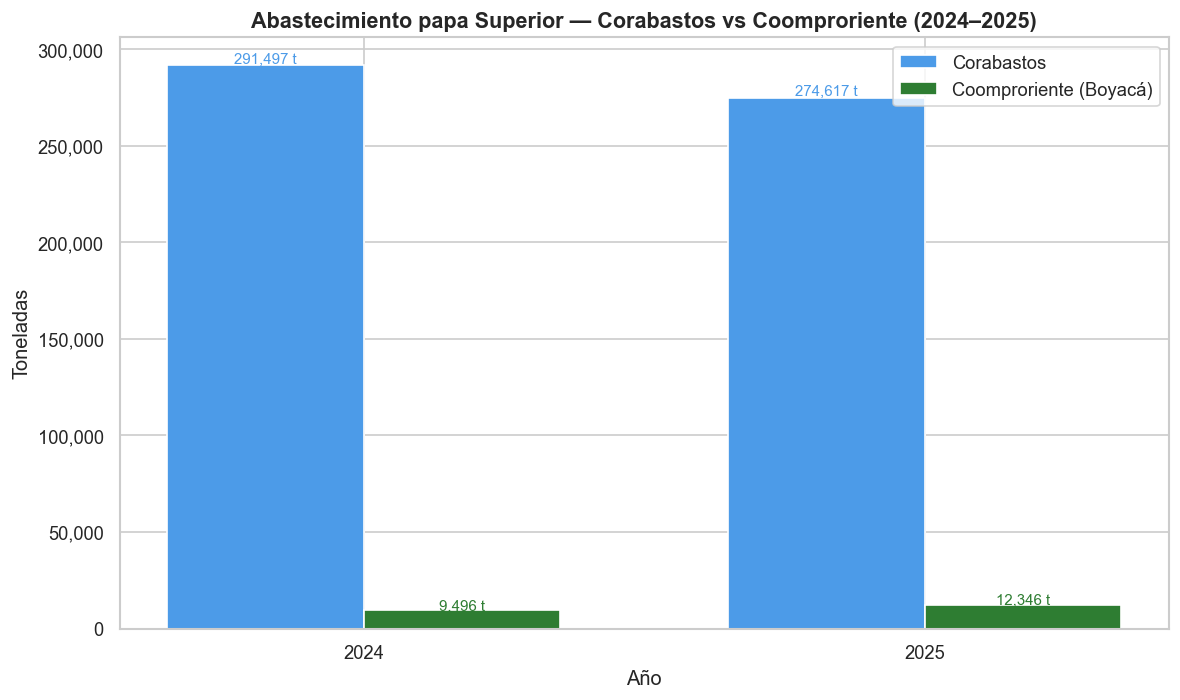

In [36]:
# --- Gráfica 1: Barras lado a lado — abastecimiento anual por central ---
import numpy as np

años_comp = [2024, 2025]
x         = np.arange(len(años_comp))
ancho     = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - ancho/2, abast_cora_a['Toneladas'], ancho,
               label='Corabastos', color='#4C9BE8', edgecolor='white')
bars2 = ax.bar(x + ancho/2, abast_comp_a['Toneladas'], ancho,
               label='Coomproriente (Boyacá)', color='#2E7D32', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f"{bar.get_height():,.0f} t", ha='center', fontsize=9, color='#4C9BE8')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{bar.get_height():,.0f} t", ha='center', fontsize=9, color='#2E7D32')

ax.set_title('Abastecimiento papa Superior — Corabastos vs Coomproriente (2024–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Toneladas')
ax.set_xticks(x)
ax.set_xticklabels(años_comp)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_comparacion_centrales_barras.png'), bbox_inches='tight')
plt.show()

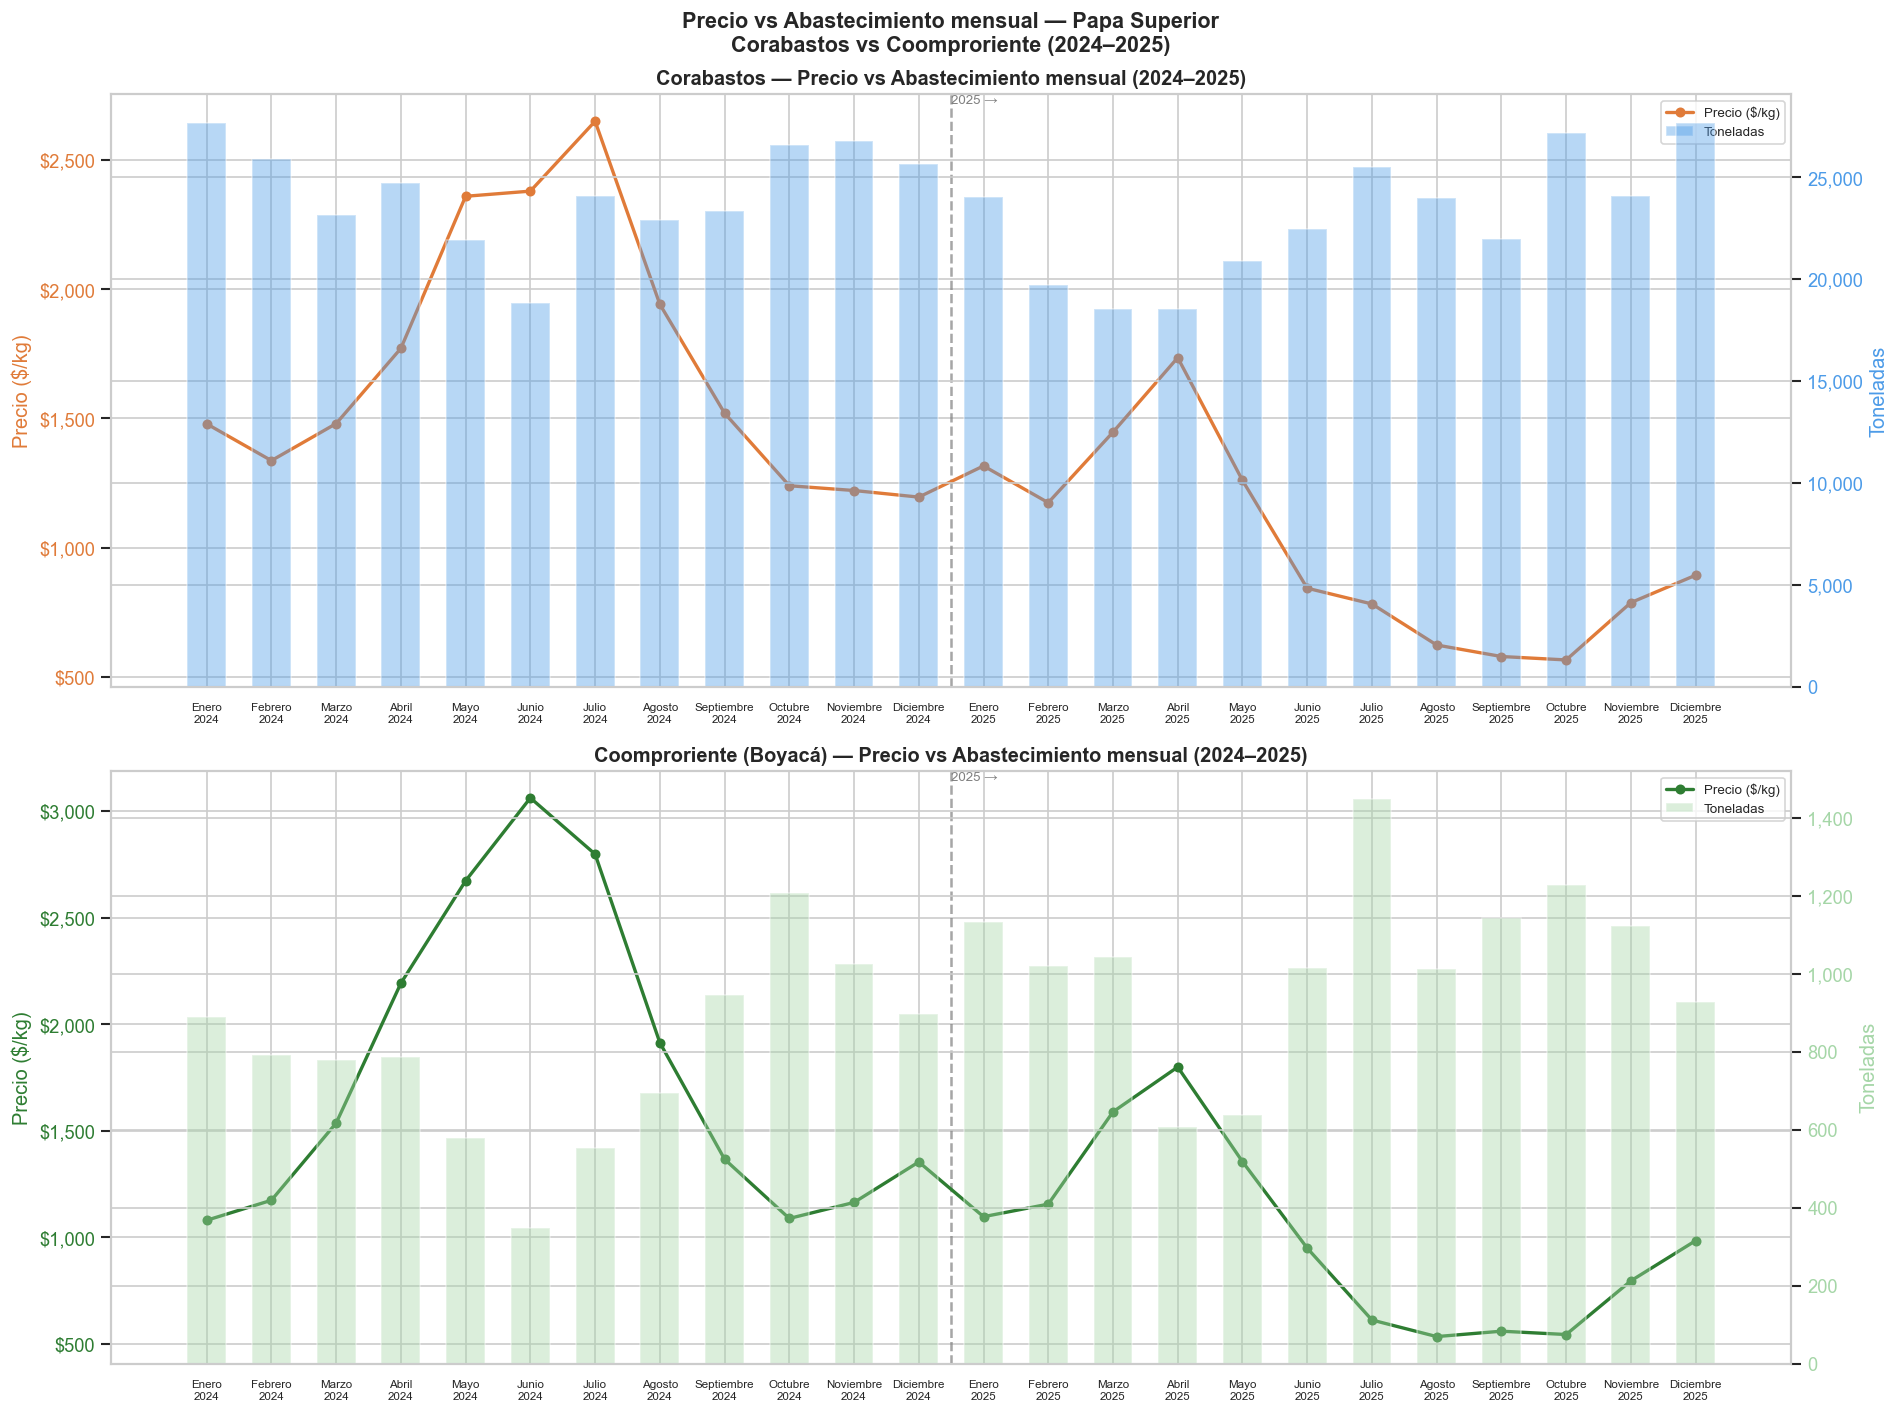

In [37]:
# --- Gráfica 3: Precio y abastecimiento mensual por central ---
# 4 paneles: abastecimiento y precio de cada central mes a mes

cora_plot = pd.merge(abast_cora_m, precio_cora_m, on=['Año','mes'], how='inner')
comp_plot = pd.merge(abast_comp_m, precio_comp_m, on=['Año','mes'], how='inner')

for df_temp in [cora_plot, comp_plot]:
    df_temp['mes'] = pd.Categorical(df_temp['mes'], categories=meses_orden_comp, ordered=True)
    df_temp.sort_values(['Año','mes'], inplace=True)
    df_temp.reset_index(drop=True, inplace=True)

def etiqueta_mes_año(df_t):
    return df_t['mes'].astype(str) + '\n' + df_t['Año'].astype(str)

etiquetas_cora = etiqueta_mes_año(cora_plot)
etiquetas_comp = etiqueta_mes_año(comp_plot)
x_cora = np.arange(len(cora_plot))
x_comp = np.arange(len(comp_plot))

fig, axes_m = plt.subplots(2, 1, figsize=(16, 12))

for ax_p, ax_t, x_vals, plot_df, etiquetas, col_p, col_t, titulo in [
    (axes_m[0], axes_m[0].twinx(), x_cora, cora_plot, etiquetas_cora,
     '#E07B39', '#4C9BE8', 'Corabastos'),
    (axes_m[1], axes_m[1].twinx(), x_comp, comp_plot, etiquetas_comp,
     '#2E7D32', '#A5D6A7', 'Coomproriente (Boyacá)')
]:
    ax_t.bar(x_vals, plot_df['Toneladas'], color=col_t, alpha=0.4, width=0.6, label='Toneladas')
    ax_t.set_ylabel('Toneladas', color=col_t)
    ax_t.tick_params(axis='y', labelcolor=col_t)
    ax_t.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

    ax_p.plot(x_vals, plot_df['precio'], marker='o', color=col_p,
              linewidth=2, markersize=5, label='Precio ($/kg)', zorder=5)
    ax_p.set_ylabel('Precio ($/kg)', color=col_p)
    ax_p.tick_params(axis='y', labelcolor=col_p)
    ax_p.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax_p.set_title(f'{titulo} — Precio vs Abastecimiento mensual (2024–2025)',
                   fontsize=12, fontweight='bold')
    ax_p.set_xticks(x_vals)
    ax_p.set_xticklabels(etiquetas, fontsize=7)

    idx_sep = len(plot_df[plot_df['Año'] == 2024])
    ax_p.axvline(x=idx_sep - 0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax_p.text(idx_sep - 0.5, ax_p.get_ylim()[1], '2025 →', fontsize=8, color='gray', va='top')

    lines1, labels1 = ax_p.get_legend_handles_labels()
    lines2, labels2 = ax_t.get_legend_handles_labels()
    ax_p.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=8)

plt.suptitle('Precio vs Abastecimiento mensual — Papa Superior\nCorabastos vs Coomproriente (2024–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED, 'grafico_precio_abast_mensual_centrales.png'), bbox_inches='tight')
plt.show()

---
## Sección 11 — Conclusiones

### ¿Qué encontramos?

Este proyecto partió de una pregunta simple: **¿el abastecimiento determina el precio de la papa Superior en Corabastos?**

La respuesta es clara: **no, o al menos no principalmente.**

---

### Hallazgos principales

**1. El abastecimiento explica muy poco el precio (R²=0.01)**  
Que lleguen más o menos toneladas de papa a Corabastos en un mes prácticamente no predice si el precio va a subir o bajar. La hipótesis inicial no se sostiene con los datos.

**2. La inflación de alimentos ayuda, pero tampoco es suficiente (R²=0.08)**  
El IPC de alimentos tiene una relación positiva con el precio — cuando la inflación sube, el precio de la papa también tiende a subir. Pero por sí sola no explica las grandes fluctuaciones.

**3. El precio del mes anterior es la variable más importante**  
Con un coeficiente de 0.84, el precio del mes anterior explica el 84% del precio actual. El precio de la papa tiene mucha **inercia**: si estuvo caro este mes, probablemente sigue caro el siguiente.

**4. Los costos de producción + estacionalidad completan el modelo (R²=0.85)**  
Al agregar fertilizantes, transporte, mano de obra y el efecto estacional (qué mes del año es), el modelo M5 explica el 85% de las variaciones del precio — con un error promedio de solo $150/kg.

---

### Patrones estacionales identificados

- **Mes más caro históricamente:** Abril ($1.413/kg promedio 2019-2025)
- **Mes más barato históricamente:** Septiembre ($928/kg promedio 2019-2025)
- El primer semestre tiende a ser más caro que el segundo

---

### Eventos atípicos

- **2020:** caída fuerte de precio y abastecimiento por el COVID-19
- **2022:** pico de precio (~$2.500/kg) por inflación global, paro camionero y crisis de fertilizantes
- **2024:** segundo pico de precio por alza en costos de producción
- **2025:** caída pronunciada de precios

---

### Corabastos vs Coomproriente (2024-2025)

Corabastos maneja aproximadamente **20 veces más volumen** que Coomproriente en Boyacá, pero los precios siguen patrones similares — lo que sugiere que ambas centrales responden a los mismos factores estructurales del mercado de papa en Colombia.

---

### Implicaciones prácticas

- **Para agricultores:** los meses de enero a abril son históricamente los más rentables para vender papa Superior en Corabastos
- **Para política pública:** las intervenciones de estabilización de precios deben considerar la inercia del precio — bajar el precio un mes tiene efecto sobre los meses siguientes
- **Para análisis futuros:** modelos de series de tiempo (ARIMA, Prophet) podrían mejorar el poder predictivo aprovechando la fuerte autocorrelación encontrada

---

### Limitaciones del estudio

- El análisis es **explicativo, no predictivo** — los modelos usan el precio del mes anterior como variable, lo que limita su uso para proyectar el futuro más allá de un mes
- No se incluyeron variables climáticas (precipitación, temperatura) que pueden afectar la cosecha
- El análisis se limita a papa **Superior** en **Corabastos** — otras variedades y centrales pueden tener dinámicas diferentes

---

> **Equipo:** Esteban Mesa · Farith · Milena · Alex  
> **Programa:** Bootcamp de Análisis de Datos 2026  
> **Repositorio:** [github.com/estebanmesa147-boop/proyecto_papa_superior-](https://github.com/estebanmesa147-boop/proyecto_papa_superior-)